## Forecast verification analysis for the SWPC 3-day F10.7 solar flux forecasts

#### Data timeframe is 1988 to November 2025. May be extended back to 1966 if I can get the OCR routine to read the RSGA files from that period which are image PDFs...

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LogNorm, TwoSlopeNorm
from scipy.stats import pearsonr

### Analyze the full 3-day forecast data obtained from RSGA.txt files from 1988 to 2025. The files were analyzed with the SWPC_RSGA.ipynb code and written to the SWPC_RSGA_F107_3-day_forecasts_1988-2025_wideformat.csv file on Nov 18, 2025.

In [106]:
#Read in the .csv file to a Pandas DataFrame
df = pd.read_csv("SWPC_RSGA_F107_3-day_forecasts_1988-2025_wideformat.csv")
df.head(20)

,issued_date,observed,predicted_day1,predicted_day2,predicted_day3
0,1988-06-01,150.0,152.0,150.0,145.0
1,1988-06-02,144.0,140.0,135.0,130.0
2,1988-06-03,145.0,140.0,135.0,130.0
3,1988-06-04,147.0,144.0,140.0,137.0
4,1988-06-05,147.0,147.0,148.0,148.0
5,1988-06-06,154.0,156.0,157.0,157.0
6,1988-06-07,160.0,160.0,160.0,160.0
7,1988-06-08,163.0,165.0,166.0,167.0
8,1988-06-09,165.0,166.0,167.0,166.0
9,1988-06-10,145.0,150.0,150.0,145.0


In [107]:
df["observed"] = pd.to_numeric(df["observed"], errors="coerce")
any_zero_obs = (df["observed"] == 0).any()
any_zero_obs

np.True_

In [108]:
df.loc[df["observed"] == 0]

,issued_date,observed,predicted_day1,predicted_day2,predicted_day3
1599,1992-10-23,0.0,150.0,150.0,145.0


In [110]:
#rename the colums to what they should be called...
for lt in [1, 2, 3]:
    df.rename(columns={f"predicted_day{lt}": f"forecast_day{lt}"}, inplace=True)
df.head()

,issued_date,observed,forecast_day1,forecast_day2,forecast_day3
0,1988-06-01,150.0,152.0,150.0,145.0
1,1988-06-02,144.0,140.0,135.0,130.0
2,1988-06-03,145.0,140.0,135.0,130.0
3,1988-06-04,147.0,144.0,140.0,137.0
4,1988-06-05,147.0,147.0,148.0,148.0


In [111]:
df.loc[df["forecast_day1"] < 20]

,issued_date,observed,forecast_day1,forecast_day2,forecast_day3
9666,2015-03-25,138.0,8.0,15.0,25.0
12291,2022-06-10,111.0,5.0,5.0,5.0
12585,2023-04-03,134.0,14.0,12.0,10.0


In [112]:
df.loc[df["forecast_day2"] < 20]

,issued_date,observed,forecast_day1,forecast_day2,forecast_day3
9666,2015-03-25,138.0,8.0,15.0,25.0
10417,2017-04-17,75.0,20.0,18.0,15.0
11989,2021-08-11,74.0,74.0,4.0,74.0
12291,2022-06-10,111.0,5.0,5.0,5.0
12585,2023-04-03,134.0,14.0,12.0,10.0


In [8]:
df.loc[df["predicted_day3"] < 20]

,issued_date,observed,predicted_day1,predicted_day2,predicted_day3
10417,2017-04-17,75.0,20.0,18.0,15.0
10647,2017-12-03,70.0,32.0,48.0,18.0
12291,2022-06-10,111.0,5.0,5.0,5.0
12585,2023-04-03,134.0,14.0,12.0,10.0


In [113]:
df = df[df["observed"] != 0].reset_index(drop=True)
df.head()

,issued_date,observed,forecast_day1,forecast_day2,forecast_day3
0,1988-06-01,150.0,152.0,150.0,145.0
1,1988-06-02,144.0,140.0,135.0,130.0
2,1988-06-03,145.0,140.0,135.0,130.0
3,1988-06-04,147.0,144.0,140.0,137.0
4,1988-06-05,147.0,147.0,148.0,148.0


In [115]:
df = df[df["forecast_day1"] >= 20].reset_index(drop=True)
df = df[df["forecast_day2"] >= 20].reset_index(drop=True)
df = df[df["forecast_day3"] >= 20].reset_index(drop=True)
df.head()

,issued_date,observed,forecast_day1,forecast_day2,forecast_day3
0,1988-06-01,150.0,152.0,150.0,145.0
1,1988-06-02,144.0,140.0,135.0,130.0
2,1988-06-03,145.0,140.0,135.0,130.0
3,1988-06-04,147.0,144.0,140.0,137.0
4,1988-06-05,147.0,147.0,148.0,148.0


In [25]:
df.tail()

,issued_date,observed,forecast_day1,forecast_day2,forecast_day3
13576,2025-12-27,178.0,175.0,170.0,160.0
13577,2025-12-28,188.0,185.0,175.0,170.0
13578,2025-12-29,196.0,175.0,170.0,165.0
13579,2025-12-30,182.0,200.0,200.0,195.0
13580,2025-12-31,171.0,170.0,165.0,160.0


In [26]:
print(len(df))

13581


In [117]:
df.to_csv("SWPC_RSGA_F107_3-day_forecasts_1988-2025_wideformat_filtered.csv", index=False)

### Read in the basic observations and SWPC forecast dataframe created in the section above. Restart point.

In [2]:
df = pd.read_csv("SWPC_RSGA_F107_3-day_forecasts_1988-2025_wideformat_filtered.csv")
df.head()

,issued_date,observed,forecast_day1,forecast_day2,forecast_day3
0,1988-06-01,150.0,152.0,150.0,145.0
1,1988-06-02,144.0,140.0,135.0,130.0
2,1988-06-03,145.0,140.0,135.0,130.0
3,1988-06-04,147.0,144.0,140.0,137.0
4,1988-06-05,147.0,147.0,148.0,148.0


#### Utility routines needed at restart

In [3]:

def compute_forecast_accuracy(df):
    """
    Assumes df has:
        issued_date, observed, predicted_day1, predicted_day2, predicted_day3
    """

    df = df.copy()
    df["issued_date"] = pd.to_datetime(df["issued_date"])
    df = df.sort_values("issued_date").reset_index(drop=True)  # already done in the original .csv file, but good to be sure.

    # Observed truth for verification
    df["observed_day1"] = df["observed"].shift(-1)
    df["observed_day2"] = df["observed"].shift(-2)
    df["observed_day3"] = df["observed"].shift(-3)

    # Forecast errors
    df["err_day1"] = df["forecast_day1"] - df["observed_day1"]
    df["err_day2"] = df["forecast_day2"] - df["observed_day2"]
    df["err_day3"] = df["forecast_day3"] - df["observed_day3"]

    df["abs_err_day1"] = df["err_day1"].abs()
    df["abs_err_day2"] = df["err_day2"].abs()
    df["abs_err_day3"] = df["err_day3"].abs()

    #Persistence forecasts = today's observed
    df["persistence_day1"] = df["observed"]
    df["persistence_day2"] = df["observed"]
    df["persistence_day3"] = df["observed"]

    #Climatology forecasts = 30-day running mean of observed
    #Following SWPC verfication report from 2013: "The skill of forecasts produced by SWPC is compared to that of 
    #                   forecasts produced by short-term (30-day) climatology, 1-day persistence, and 27-day recurrence"
    df["climatology_day1"] = df["observed"].rolling(30, min_periods=1).mean() 
    df["climatology_day2"] = df["observed"].shift(1).rolling(30, min_periods=1).mean() 
    df["climatology_day3"] = df["observed"].shift(2).rolling(30, min_periods=1).mean()    

    # Recurrence forecasts = observed 27 days ago
    df["recurrence_day1"] = df["observed"].shift(27)
    df["recurrence_day2"] = df["observed"].shift(26)
    df["recurrence_day3"] = df["observed"].shift(25)  

    # refence forecast for skill score calculations: 3-day running mean of observed as per SWPC verfication report from 2013
    df["3-day mean reference"] = df["observed"].rolling(3, min_periods=3).mean()
    
    return df

# ------------------------------------------------------------
# 🟧 SWPC forecast skill 
# ------------------------------------------------------------
def compute_swpc_skill(df, ref):
    df = df.copy()

    # SWPC skill = 1 - (MAE_model / MAE_reference)
    mae_model = [
        df["abs_err_day1"].mean(),
        df["abs_err_day2"].mean(),
        df["abs_err_day3"].mean()
    ]
    mae_reference = [
        (df["observed_day1"] - ref).abs().mean(),
        (df["observed_day2"] - ref).abs().mean(),
        (df["observed_day3"] - ref).abs().mean()
    ]

    return {
        "skill_day1_swpc": 1 - mae_model[0]/mae_reference[0],
        "skill_day2_swpc": 1 - mae_model[1]/mae_reference[1],
        "skill_day3_swpc": 1 - mae_model[2]/mae_reference[2],
    }


# ------------------------------------------------------------

# 🟦 Persistence skill
# ------------------------------------------------------------

def compute_persistence_skill(df, ref):
    df = df.copy()

    # Persistence forecasts = today's observed
    df["persistence_day1"] = df["observed"]
    df["persistence_day2"] = df["observed"]
    df["persistence_day3"] = df["observed"]

    # Persistence errors
    df["pers_err_day1"] = df["persistence_day1"] - df["observed_day1"]
    df["pers_err_day2"] = df["persistence_day2"] - df["observed_day2"]
    df["pers_err_day3"] = df["persistence_day3"] - df["observed_day3"]

    mae_reference = [ 
        (df["observed_day1"] - ref).abs().mean(),
        (df["observed_day2"] - ref).abs().mean(),
        (df["observed_day3"] - ref).abs().mean()
    ]

    mae_pers = [
        df["pers_err_day1"].abs().mean(),
        df["pers_err_day2"].abs().mean(),
        df["pers_err_day3"].abs().mean()
    ]

    return {
        "skill_day1_persistence": 1 - mae_pers[0]/mae_reference[0],
        "skill_day2_persistence": 1 - mae_pers[1]/mae_reference[1],
        "skill_day3_persistence": 1 - mae_pers[2]/mae_reference[2],
    }


# ------------------------------------------------------------
# 🟩 Climatology skill: SWPC verification report from 2013 used 30-day running mean as climatology forecast.
# ------------------------------------------------------------

def compute_climatology_skill(df, ref):
# df = dataframe with accuracy metrics computed (output of compute_forecast_accuracy), i.e. df_acc
# ref = reference forecast for skill score calculations, e.g. mean of observed values over entire period of verification as in SWPC verfication report from 2013, or 3-day running mean of observed as per SWPC verfication report from 2013

    df = df.copy()

    df["clim"] = df["observed"].rolling(30, min_periods=1).mean()

    df["clim_err_day1"] = df["climatology_day1"] - df["observed_day1"]
    df["clim_err_day2"] = df["climatology_day2"] - df["observed_day2"]
    df["clim_err_day3"] = df["climatology_day3"] - df["observed_day3"]

    mae_reference = [ 
        (df["observed_day1"] - ref).abs().mean(),
        (df["observed_day2"] - ref).abs().mean(),
        (df["observed_day3"] - ref).abs().mean()
    ]

    mae_clim = [
        df["clim_err_day1"].abs().mean(),
        df["clim_err_day2"].abs().mean(),
        df["clim_err_day3"].abs().mean()
    ]

    return {
        "skill_day1_climatology": 1 - mae_clim[0]/mae_reference[0],
        "skill_day2_climatology": 1 - mae_clim[1]/mae_reference[1],
        "skill_day3_climatology": 1 - mae_clim[2]/mae_reference[2],
    }

# ------------------------------------------------------------
# 🟩 Recurrence skill: recurrence in the solar context usually refers to solar rotational periodicity.
#    Active regions that cause F10.7 effects will tend to recur on roughly 27-day periods. 
# ------------------------------------------------------------
def compute_recurrence_skill(df, ref):
    df = df.copy()

    df["recurrence_day1"] = df["observed"].shift(27)
    df["recurrence_day2"] = df["observed"].shift(26)
    df["recurrence_day3"] = df["observed"].shift(25)

    df["rec_err_day1"] = df["recurrence_day1"] - df["observed_day1"]
    df["rec_err_day2"] = df["recurrence_day2"] - df["observed_day2"]
    df["rec_err_day3"] = df["recurrence_day3"] - df["observed_day3"]

    mae_reference = [ 
        (df["observed_day1"] - ref).abs().mean(),
        (df["observed_day2"] - ref).abs().mean(),
        (df["observed_day3"] - ref).abs().mean()
    ]

    mae_rec = [
        df["rec_err_day1"].abs().mean(),
        df["rec_err_day2"].abs().mean(),
        df["rec_err_day3"].abs().mean()
    ]

    return {
        "skill_day1_recurrence": 1 - mae_rec[0]/mae_reference[0],
        "skill_day2_recurrence": 1 - mae_rec[1]/mae_reference[1],
        "skill_day3_recurrence": 1 - mae_rec[2]/mae_reference[2],
    }

# ------------------------------------------------------------
# 🟧 General forecast metrics specific to SWPC forecast in df dataframe. Generic routine is in next section below...
#     • MAE
#     • RMSE
#     • Pearson correlation
# ------------------------------------------------------------

def compute_swpc_forecast_metrics(df_acc):

    out = {}

    # Loop through the 3 forecast horizons
    for day in [1, 2, 3]:
        err = df_acc[f"err_day{day}"]

        # MAE
        mae = err.abs().mean()
        mae_std = err.abs().std() / np.sqrt(len(err))  # standard error of the mean absolute error

        # RMSE
        rmse = np.sqrt((err**2).mean())
        rmse_std = np.sqrt((err**2).std() / np.sqrt(len(err)))  # standard error of the root mean squared error

        # Pearson correlation
        # Drop NaN pairs (last few rows missing observed_day2/3)
        valid = df_acc[[f"forecast_day{day}", f"observed_day{day}"]].dropna()
        r = valid.corr().iloc[0, 1]

        out.update({
            f"mae_day{day}": mae,
            f"mae_day{day}_std": mae_std,
            f"rmse_day{day}": rmse,
            f"rmse_day{day}_std": rmse_std,
            f"corr_day{day}": r
        })

    return out


### Create a new dataframe with SWPC forecasts, observations by leadtime, errors of SWPC forecasts, reference forecasts, and year column. Also create a forecast metrics dataframe for the entire 1988-2025 period.

In [4]:
# Main analysis for entire 1988-2025 period: last run 27-Feb-2026

df_acc = compute_forecast_accuracy(df)


#### clean up the new dataframe by removing NaNs 

In [5]:
num_nans = df_acc.isna().sum()
num_nans

issued_date              0
observed                 0
forecast_day1            0
forecast_day2            0
forecast_day3            0
observed_day1            1
observed_day2            2
observed_day3            3
err_day1                 1
err_day2                 2
err_day3                 3
abs_err_day1             1
abs_err_day2             2
abs_err_day3             3
persistence_day1         0
persistence_day2         0
persistence_day3         0
climatology_day1         0
climatology_day2         1
climatology_day3         2
recurrence_day1         27
recurrence_day2         26
recurrence_day3         25
3-day mean reference     2
dtype: int64

In [7]:
df_acc[df_acc.isna().any(axis=1)]

,issued_date,observed,forecast_day1,forecast_day2,forecast_day3,observed_day1,observed_day2,observed_day3,err_day1,err_day2,...,persistence_day1,persistence_day2,persistence_day3,climatology_day1,climatology_day2,climatology_day3,recurrence_day1,recurrence_day2,recurrence_day3,3-day mean reference
0,1988-06-01,150.0,152.0,150.0,145.0,144.0,145.0,147.0,8.0,5.0,...,150.0,150.0,150.0,150.000000,NaN,NaN,NaN,NaN,NaN,NaN
1,1988-06-02,144.0,140.0,135.0,130.0,145.0,147.0,147.0,-5.0,-12.0,...,144.0,144.0,144.0,147.000000,150.000000,NaN,NaN,NaN,NaN,NaN
2,1988-06-03,145.0,140.0,135.0,130.0,147.0,147.0,154.0,-7.0,-12.0,...,145.0,145.0,145.0,146.333333,147.000000,150.000000,NaN,NaN,NaN,146.333333
3,1988-06-04,147.0,144.0,140.0,137.0,147.0,154.0,160.0,-3.0,-14.0,...,147.0,147.0,147.0,146.500000,146.333333,147.000000,NaN,NaN,NaN,145.333333
4,1988-06-05,147.0,147.0,148.0,148.0,154.0,160.0,163.0,-7.0,-12.0,...,147.0,147.0,147.0,146.600000,146.500000,146.333333,NaN,NaN,NaN,146.333333
5,1988-06-06,154.0,156.0,157.0,157.0,160.0,163.0,165.0,-4.0,-6.0,...,154.0,154.0,154.0,147.833333,146.600000,146.500000,NaN,NaN,NaN,149.333333
6,1988-06-07,160.0,160.0,160.0,160.0,163.0,165.0,145.0,-3.0,-5.0,...,160.0,160.0,160.0,149.571429,147.833333,146.600000,NaN,NaN,NaN,153.666667
7,1988-06-08,163.0,165.0,166.0,167.0,165.0,145.0,134.0,0.0,21.0,...,163.0,163.0,163.0,151.250000,149.571429,147.833333,NaN,NaN,NaN,159.000000
8,1988-06-09,165.0,166.0,167.0,166.0,145.0,134.0,122.0,21.0,33.0,...,165.0,165.0,165.0,152.777778,151.250000,149.571429,NaN,NaN,NaN,162.666667
9,1988-06-10,145.0,150.0,150.0,145.0,134.0,122.0,112.0,16.0,28.0,...,145.0,145.0,145.0,152.000000,152.777778,151.250000,NaN,NaN,NaN,157.666667


#### Boundary effects: last three days in file can't compare forecasts to future observations...

In [8]:
print(len(df_acc))

13581


In [9]:
df_acc.dropna(inplace=True)
print(len(df_acc))

13551


In [10]:
print(str(df_acc.head()))

   issued_date  observed  forecast_day1  forecast_day2  forecast_day3  \
27  1988-06-28     178.0          185.0          180.0          175.0   
28  1988-06-29     183.0          185.0          180.0          170.0   
29  1988-06-30     184.0          184.0          184.0          183.0   
30  1988-07-01     193.0          194.0          194.0          193.0   
31  1988-07-02     192.0          192.0          192.0          191.0   

    observed_day1  observed_day2  observed_day3  err_day1  err_day2  ...  \
27          183.0          184.0          193.0       2.0      -4.0  ...   
28          184.0          193.0          192.0       1.0     -13.0  ...   
29          193.0          192.0          187.0      -9.0      -8.0  ...   
30          192.0          187.0          175.0       2.0       7.0  ...   
31          187.0          175.0          166.0       5.0      17.0  ...   

    persistence_day1  persistence_day2  persistence_day3  climatology_day1  \
27             178.0      

In [11]:
df_acc.tail()

,issued_date,observed,forecast_day1,forecast_day2,forecast_day3,observed_day1,observed_day2,observed_day3,err_day1,err_day2,...,persistence_day1,persistence_day2,persistence_day3,climatology_day1,climatology_day2,climatology_day3,recurrence_day1,recurrence_day2,recurrence_day3,3-day mean reference
13573,2025-12-24,134.0,150.0,155.0,160.0,163.0,166.0,178.0,-13.0,-11.0,...,134.0,134.0,134.0,151.666667,151.066667,150.333333,120.0,138.0,160.0,136.333333
13574,2025-12-25,163.0,165.0,170.0,175.0,166.0,178.0,188.0,-1.0,-8.0,...,163.0,163.0,163.0,153.233333,151.666667,151.066667,138.0,160.0,180.0,146.333333
13575,2025-12-26,166.0,170.0,175.0,170.0,178.0,188.0,196.0,-8.0,-13.0,...,166.0,166.0,166.0,154.766667,153.233333,151.666667,160.0,180.0,196.0,154.333333
13576,2025-12-27,178.0,175.0,170.0,160.0,188.0,196.0,182.0,-13.0,-26.0,...,178.0,178.0,178.0,156.700000,154.766667,153.233333,180.0,196.0,200.0,169.000000
13577,2025-12-28,188.0,185.0,175.0,170.0,196.0,182.0,171.0,-11.0,-7.0,...,188.0,188.0,188.0,158.366667,156.700000,154.766667,196.0,200.0,200.0,177.333333


In [12]:
df_acc["issued_date"] = pd.to_datetime(df_acc["issued_date"])
df_acc["year"] = df_acc["issued_date"].dt.year
df_acc.head()

,issued_date,observed,forecast_day1,forecast_day2,forecast_day3,observed_day1,observed_day2,observed_day3,err_day1,err_day2,...,persistence_day2,persistence_day3,climatology_day1,climatology_day2,climatology_day3,recurrence_day1,recurrence_day2,recurrence_day3,3-day mean reference,year
27,1988-06-28,178.0,185.0,180.0,175.0,183.0,184.0,193.0,2.0,-4.0,...,178.0,178.0,137.035714,135.518519,134.769231,150.0,144.0,145.0,162.666667,1988
28,1988-06-29,183.0,185.0,180.0,170.0,184.0,193.0,192.0,1.0,-13.0,...,183.0,183.0,138.620690,137.035714,135.518519,144.0,145.0,147.0,172.000000,1988
29,1988-06-30,184.0,184.0,184.0,183.0,193.0,192.0,187.0,-9.0,-8.0,...,184.0,184.0,140.133333,138.620690,137.035714,145.0,147.0,147.0,181.666667,1988
30,1988-07-01,193.0,194.0,194.0,193.0,192.0,187.0,175.0,2.0,7.0,...,193.0,193.0,141.566667,140.133333,138.620690,147.0,147.0,154.0,186.666667,1988
31,1988-07-02,192.0,192.0,192.0,191.0,187.0,175.0,166.0,5.0,17.0,...,192.0,192.0,143.166667,141.566667,140.133333,147.0,154.0,160.0,189.666667,1988


In [13]:
print(len(df_acc))
df_acc.to_csv("SWPC_RSGA_F107_3-day_forecasts_1988-2025_wideformat_filtered_with_error_and_reference_forecasts.csv", index=False)

13551


#### The requisite plot of daily F10.7 for the entire range. Also plot the sunspot number...

In [14]:
df_acc['f107_27d'] = (
    df_acc['observed']
    .rolling(window=27, center=True, min_periods=14)
    .mean()
)

In [15]:
df_acc['f107_81d'] = (
    df_acc['observed']
    .rolling(window=81, center=True, min_periods=41)
    .mean()
)

In [16]:
#read the sunspot number data for 1988-2025 from the SILSO dataset
# https://www.sidc.be/silso/datafiles
# using the "Daily mean total sunspot number" data, which is the second column in the file "SN_d_tot_V2.0.txt" (first column is date in format YYYYMM)
sunspot_data = pd.read_csv("SN_d_tot_V2.0.txt", delimiter="\s+", header=None, names=["year", "month", "day", "date fraction","total sunspot_number", "std_dev", "num_obs", "flag"])
#sunspot_data["date"] = pd.to_datetime(sunspot_data["date"], format="%Y%m")
sunspot_data.head()

<>:4: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:4: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/jr/spvdphtj6670vttvs7gq9b540000gp/T/ipykernel_19925/2286231658.py:4: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  sunspot_data = pd.read_csv("SN_d_tot_V2.0.txt", delimiter="\s+", header=None, names=["year", "month", "day", "date fraction","total sunspot_number", "std_dev", "num_obs", "flag"])
/var/folders/jr/spvdphtj6670vttvs7gq9b540000gp/T/ipykernel_19925/2286231658.py:4: DtypeWarning: Columns (0: flag) have mixed types. Specify dtype option on import or set low_memory=False.
  sunspot_data = pd.read_csv("SN_d_tot_V2.0.txt", delimiter="\s+", header=None, names=["year", 

,year,month,day,date fraction,total sunspot_number,std_dev,num_obs,flag
0,1818,1,1,1818.001,-1,-1.0,0,NaN
1,1818,1,2,1818.004,-1,-1.0,0,NaN
2,1818,1,3,1818.007,-1,-1.0,0,NaN
3,1818,1,4,1818.010,-1,-1.0,0,NaN
4,1818,1,5,1818.012,-1,-1.0,0,NaN


In [17]:
# Build datetime
sunspot_data["issued_date"] = pd.to_datetime(
    sunspot_data[["year", "month", "day"]]
)

# Replace missing value (-1) with NaN
sunspot_data["total sunspot_number"] = sunspot_data["total sunspot_number"].replace(-1, pd.NA)

sunspot_data.tail()


,year,month,day,date fraction,total sunspot_number,std_dev,num_obs,flag,issued_date
76025,2026,2,24,2026.149,6,12.2,29,*,2026-02-24
76026,2026,2,25,2026.152,15,8.4,34,*,2026-02-25
76027,2026,2,26,2026.155,34,10.9,41,*,2026-02-26
76028,2026,2,27,2026.158,46,10.7,29,*,2026-02-27
76029,2026,2,28,2026.160,58,10.0,23,*,2026-02-28


In [18]:
df_acc = df_acc.merge(
    sunspot_data[["issued_date", "total sunspot_number"]],
    left_on="issued_date",
    right_on="issued_date",
    how="left"
)

In [19]:
df_acc["ssn_81d"] = (
    df_acc["total sunspot_number"]
    .rolling(window=81, center=True, min_periods=41)
    .mean()
)

In [20]:
df_acc

,issued_date,observed,forecast_day1,forecast_day2,forecast_day3,observed_day1,observed_day2,observed_day3,err_day1,err_day2,...,climatology_day3,recurrence_day1,recurrence_day2,recurrence_day3,3-day mean reference,year,f107_27d,f107_81d,total sunspot_number,ssn_81d
0,1988-06-28,178.0,185.0,180.0,175.0,183.0,184.0,193.0,2.0,-4.0,...,134.769231,150.0,144.0,145.0,162.666667,1988,164.214286,157.853659,142,139.073171
1,1988-06-29,183.0,185.0,180.0,170.0,184.0,193.0,192.0,1.0,-13.0,...,135.518519,144.0,145.0,147.0,172.000000,1988,162.133333,158.404762,148,140.523810
2,1988-06-30,184.0,184.0,184.0,183.0,193.0,192.0,187.0,-9.0,-8.0,...,137.035714,145.0,147.0,147.0,181.666667,1988,160.625000,158.906977,148,142.232558
3,1988-07-01,193.0,194.0,194.0,193.0,192.0,187.0,175.0,2.0,7.0,...,138.620690,147.0,147.0,154.0,186.666667,1988,159.705882,159.386364,160,143.318182
4,1988-07-02,192.0,192.0,192.0,191.0,187.0,175.0,166.0,5.0,17.0,...,140.133333,147.0,154.0,160.0,189.666667,1988,158.944444,159.688889,167,143.888889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13546,2025-12-24,134.0,150.0,155.0,160.0,163.0,166.0,178.0,-13.0,-11.0,...,150.333333,120.0,138.0,160.0,136.333333,2025,136.555556,147.022222,131,105.933333
13547,2025-12-25,163.0,165.0,170.0,175.0,166.0,178.0,188.0,-1.0,-8.0,...,151.066667,138.0,160.0,180.0,146.333333,2025,136.000000,147.068182,128,106.000000
13548,2025-12-26,166.0,170.0,175.0,170.0,178.0,188.0,196.0,-8.0,-13.0,...,151.666667,160.0,180.0,196.0,154.333333,2025,136.062500,147.418605,126,106.139535
13549,2025-12-27,178.0,175.0,170.0,160.0,188.0,196.0,182.0,-13.0,-26.0,...,153.233333,180.0,196.0,200.0,169.000000,2025,137.000000,147.785714,150,106.976190


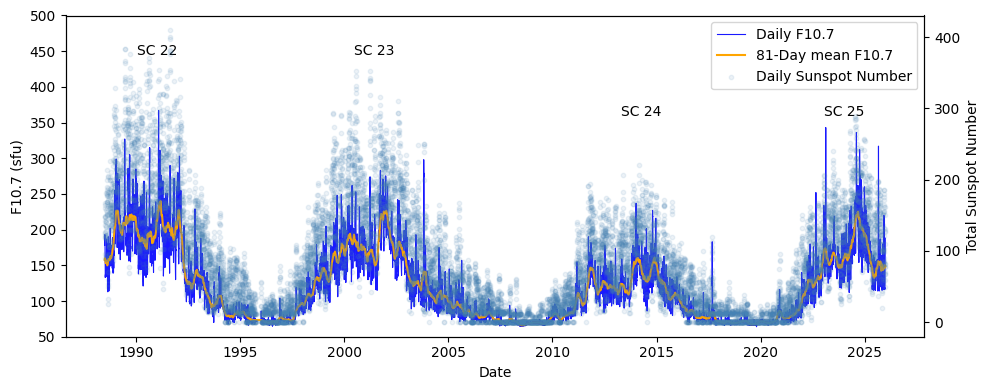

In [21]:
#Make the combined F10.7 and sunspot number plot for the period of 1988-2025. F10.7 on left y-axis, sunspot number on right y-axis, date on x-axis.
fig, ax1 = plt.subplots(figsize=(10,4))

# F10.7
ax1.plot(df_acc["issued_date"],
         df_acc["observed"],
         alpha=0.9,
         color="blue",
         linewidth=0.8,
         label="Daily F10.7")

ax1.plot(df_acc["issued_date"],
         df_acc["f107_81d"],
         linewidth=1.5,
         color="orange",
         label="81-Day mean F10.7")

ax1.set_xlabel("Date")
ax1.set_ylabel("F10.7 (sfu)")
ax1.set_ylim(50, 500)

# Twin axis for sunspots
ax2 = ax1.twinx()

ax2.scatter(df_acc["issued_date"],
         df_acc["total sunspot_number"],
         marker="o",
         s=10,
         alpha=0.1,
         color="steelblue",
         label="Daily Sunspot Number")

ax2.set_ylabel("Total Sunspot Number")

# Solar cycle boundaries (official minima)
cycle_starts = {
    22: pd.Timestamp("1986-09-01"),
    23: pd.Timestamp("1996-05-01"),
    24: pd.Timestamp("2008-12-01"),
    25: pd.Timestamp("2019-12-01")
}

# Add vertical lines at minima
#for cyc, date in cycle_starts.items():
#    ax1.axvline(date, linestyle="--", linewidth=1)

# Label cycles at approximate midpoints
cycle_midpoints = {
    22: [pd.Timestamp("1991-01-01"), ax1.get_ylim()[1] * 0.92],
    23: [pd.Timestamp("2001-06-01"), ax1.get_ylim()[1] * 0.92],
    24: [pd.Timestamp("2014-04-01"), ax1.get_ylim()[1] * 0.75],
    25: [pd.Timestamp("2024-01-01"), ax1.get_ylim()[1] * 0.75]
}

#ypos = ax1.get_ylim()[1] * 0.92

for cyc, (date, ypos) in cycle_midpoints.items():
    ax1.text(date, ypos,
             f"SC {cyc}",
             ha="center",
             va="top",
             fontsize=10)
    
# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

#plt.title("Daily F10.7 and SILSO Total Sunspot Number")
plt.tight_layout()
#plt.savefig("verification_paper_figures/DRAO_F10.7_and_SILSO_Sunspot_Number_1988-2025.png", dpi=300)
plt.show()

In [22]:
cyc = {22:[1.0, pd.Timestamp("1996-05-01")], 23:[1.0, pd.Timestamp("2008-12-01")], 24:[1.0, pd.Timestamp("2019-12-01")], 25:[0.8, pd.Timestamp("2023-01-01")]}

In [23]:
for cyc, (alpha, date) in cyc.items():
    ax1.axvline(date, linestyle="--", linewidth=1, alpha=alpha)

### Create skill scores and various metrics for swpc forecast:

#### Reference forecast = mean of all observations over period 1988-2025, as in SWPC verification report of 2014.

In [24]:
ref_all = df_acc["observed"].mean()  # reference forecast for skill score calculations, e.g. mean of observed values over entire period of verification as in SWPC verfication report from 2014.

swpc_metrics  = compute_swpc_forecast_metrics(df_acc)
swpc_skill = compute_swpc_skill(df_acc, ref_all)
persistence_skill = compute_persistence_skill(df_acc, ref_all)
climatology_skill  = compute_climatology_skill(df_acc, ref_all)
recurrence_skill = compute_recurrence_skill(df_acc, ref_all)

forecast_metrics = {
    **swpc_metrics,
    **swpc_skill,
    **persistence_skill,
    **climatology_skill,
    **recurrence_skill
}

forecast_metrics_all = pd.DataFrame([forecast_metrics]) 
to_csv_path = "SWPC_F10.7_3-day_forecast_metrics_ref=mean-all_1988-2025.csv"
forecast_metrics_all.to_csv(to_csv_path, index=False)
print(forecast_metrics_all.to_string(index=False))


 mae_day1  mae_day1_std  rmse_day1  rmse_day1_std  corr_day1  mae_day2  mae_day2_std  rmse_day2  rmse_day2_std  corr_day2  mae_day3  mae_day3_std  rmse_day3  rmse_day3_std  corr_day3  skill_day1_swpc  skill_day2_swpc  skill_day3_swpc  skill_day1_persistence  skill_day2_persistence  skill_day3_persistence  skill_day1_climatology  skill_day2_climatology  skill_day3_climatology  skill_day1_recurrence  skill_day2_recurrence  skill_day3_recurrence
 4.341894      0.049261   7.192571       1.751602   0.989574  6.436647      0.067796  10.183806       1.906786   0.979043  8.359014      0.086027  13.044208        2.15393   0.965487         0.894689         0.843881          0.79725                0.894011                0.831363                0.772984                0.692234                0.673903                 0.65844               0.609118               0.609114               0.609081


#### Reference forecast = rollling 3-day mean 

In [25]:
ref_3d = df_acc["observed"].rolling(window=3, center=False).mean()  # reference forecast for skill score calculations, e.g. mean of observed values over entire period of verification as in SWPC verfication report from 2014.

swpc_metrics  = compute_swpc_forecast_metrics(df_acc)
swpc_skill = compute_swpc_skill(df_acc, ref_3d)
persistence_skill = compute_persistence_skill(df_acc, ref_3d)
climatology_skill  = compute_climatology_skill(df_acc, ref_3d)
recurrence_skill = compute_recurrence_skill(df_acc, ref_3d)

forecast_metrics = {
    **swpc_metrics,
    **swpc_skill,
    **persistence_skill,
    **climatology_skill,
    **recurrence_skill
}

forecast_metrics_3d = pd.DataFrame([forecast_metrics]) 
to_csv_path = "SWPC_F10.7_3-day_forecast_metrics_ref=mean-3d_1988-2025.csv"
forecast_metrics_3d.to_csv(to_csv_path, index=False)
print(forecast_metrics_3d.to_string(index=False))


 mae_day1  mae_day1_std  rmse_day1  rmse_day1_std  corr_day1  mae_day2  mae_day2_std  rmse_day2  rmse_day2_std  corr_day2  mae_day3  mae_day3_std  rmse_day3  rmse_day3_std  corr_day3  skill_day1_swpc  skill_day2_swpc  skill_day3_swpc  skill_day1_persistence  skill_day2_persistence  skill_day3_persistence  skill_day1_climatology  skill_day2_climatology  skill_day3_climatology  skill_day1_recurrence  skill_day2_recurrence  skill_day3_recurrence
 4.341894      0.049261   7.192571       1.751602   0.989574  6.436647      0.067796  10.183806       1.906786   0.979043  8.359014      0.086027  13.044208        2.15393   0.965487         0.332937         0.281876         0.251864                 0.32864                0.224293                0.162324               -0.949462               -0.500001               -0.260339              -1.475937              -0.798022              -0.442469


### Read in the forecast accuracy and metrics dataframes created in the previous section. Restart point.

In [26]:
df_acc = pd.read_csv("SWPC_RSGA_F107_3-day_forecasts_1988-2025_wideformat_filtered_with_error_and_reference_forecasts.csv")
df_acc.head()

,issued_date,observed,forecast_day1,forecast_day2,forecast_day3,observed_day1,observed_day2,observed_day3,err_day1,err_day2,...,persistence_day2,persistence_day3,climatology_day1,climatology_day2,climatology_day3,recurrence_day1,recurrence_day2,recurrence_day3,3-day mean reference,year
0,1988-06-28,178.0,185.0,180.0,175.0,183.0,184.0,193.0,2.0,-4.0,...,178.0,178.0,137.035714,135.518519,134.769231,150.0,144.0,145.0,162.666667,1988
1,1988-06-29,183.0,185.0,180.0,170.0,184.0,193.0,192.0,1.0,-13.0,...,183.0,183.0,138.620690,137.035714,135.518519,144.0,145.0,147.0,172.000000,1988
2,1988-06-30,184.0,184.0,184.0,183.0,193.0,192.0,187.0,-9.0,-8.0,...,184.0,184.0,140.133333,138.620690,137.035714,145.0,147.0,147.0,181.666667,1988
3,1988-07-01,193.0,194.0,194.0,193.0,192.0,187.0,175.0,2.0,7.0,...,193.0,193.0,141.566667,140.133333,138.620690,147.0,147.0,154.0,186.666667,1988
4,1988-07-02,192.0,192.0,192.0,191.0,187.0,175.0,166.0,5.0,17.0,...,192.0,192.0,143.166667,141.566667,140.133333,147.0,154.0,160.0,189.666667,1988


In [27]:
forecast_metrics_all = pd.read_csv("SWPC_F10.7_3-day_forecast_metrics_ref=mean-all_1988-2025.csv")
forecast_metrics_all.head()

,mae_day1,mae_day1_std,rmse_day1,rmse_day1_std,corr_day1,mae_day2,mae_day2_std,rmse_day2,rmse_day2_std,corr_day2,...,skill_day3_swpc,skill_day1_persistence,skill_day2_persistence,skill_day3_persistence,skill_day1_climatology,skill_day2_climatology,skill_day3_climatology,skill_day1_recurrence,skill_day2_recurrence,skill_day3_recurrence
0,4.341894,0.049261,7.192571,1.751602,0.989574,6.436647,0.067796,10.183806,1.906786,0.979043,...,0.79725,0.894011,0.831363,0.772984,0.692234,0.673903,0.65844,0.609118,0.609114,0.609081


In [55]:
forecast_metrics_3d = pd.read_csv("SWPC_F10.7_3-day_forecast_metrics_ref=mean-3d_1988-2025.csv")
forecast_metrics_3d.head()

,mae_day1,mae_day1_std,rmse_day1,rmse_day1_std,corr_day1,mae_day2,mae_day2_std,rmse_day2,rmse_day2_std,corr_day2,...,skill_day3_swpc,skill_day1_persistence,skill_day2_persistence,skill_day3_persistence,skill_day1_climatology,skill_day2_climatology,skill_day3_climatology,skill_day1_recurrence,skill_day2_recurrence,skill_day3_recurrence
0,4.341894,0.049261,7.192571,1.751602,0.989574,6.436647,0.067796,10.183806,1.906786,0.979043,...,0.251864,0.32864,0.224293,0.162324,-0.949462,-0.500001,-0.260339,-1.475937,-0.798022,-0.442469


### Plot SWPC joint distributions of forecasts vs. observations for various leadtimes. 

In [28]:
# 3D histogram of 1-day leadtime forecast vs. observations 

from matplotlib.pyplot import hist

def plot_3d_histogram(df,
                        obs_col="observed_day1",
                        fcst_col="forecast_day1",
                        bins=20,
                        log_height=False,
                        sqrt_height=True   ):

    obs = df[obs_col].values
    fcst = df[fcst_col].values

    # Compute 2D histogram
    hist, xedges, yedges = np.histogram2d(obs, fcst, bins=bins)

    # Bin widths
    dx = (xedges[1] - xedges[0]) * 0.9
    dy = (yedges[1] - yedges[0]) * 0.9

    # Flatten for bar3d
    xpos, ypos = np.meshgrid(xedges[:-1], yedges[:-1], indexing='ij')
    xpos = xpos.ravel()
    ypos = ypos.ravel()
    dz = hist.ravel().astype(float)
    mask = dz > 0
    xpos = xpos[mask]
    ypos = ypos[mask]
    dz = dz[mask]

    # Height transformation
    if log_height:
        z_heights = np.log10(dz + 1)   # compress tall bins
    elif sqrt_height:
        z_heights = np.sqrt(dz)
    else:
        z_heights = dz

    zpos = np.zeros_like(z_heights)
    

    # Color scale uses REAL frequencies (not log).
    #norm = Normalize(vmin=dz.min(), vmax=dz.max())
    #colors = cm.viridis(norm(dz))
    
    cmap = plt.get_cmap("viridis").copy()
    cmap.set_under("white")   # color for values below vmin

    norm = plt.Normalize(vmin=1, vmax=dz.max())
    colors = cmap(norm(dz))


    # Create figure
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection="3d")

    # Draw bars
    ax.bar3d(
        xpos, ypos, zpos,
        dx, dy, z_heights,
        color=colors,
        shade=True
    )

    # Axis labels
    ax.set_xlabel("Observed F10.7")
    ax.set_ylabel("Forecast (Day 1)")
    ax.set_zlabel("log10(Frequency + 1)" if log_height else "Frequency")

    ax.set_title("3-D Histogram of Observed vs. 1-Day Lead Time Forecast F10.7: 1988-2025\n"
                "(Log Height, Frequency Colorbar)")

    # Add colorbar
    mappable = cm.ScalarMappable(norm=norm, cmap=cm.viridis)
    mappable.set_array(dz)
    cbar = plt.colorbar(mappable, ax=ax, shrink=0.75)
    cbar.set_label("Frequency (linear scale)")
    
    #plt.savefig("verification_paper_figures/SWPC_day1_3D_frequency.png", dpi=300)
    plt.show()


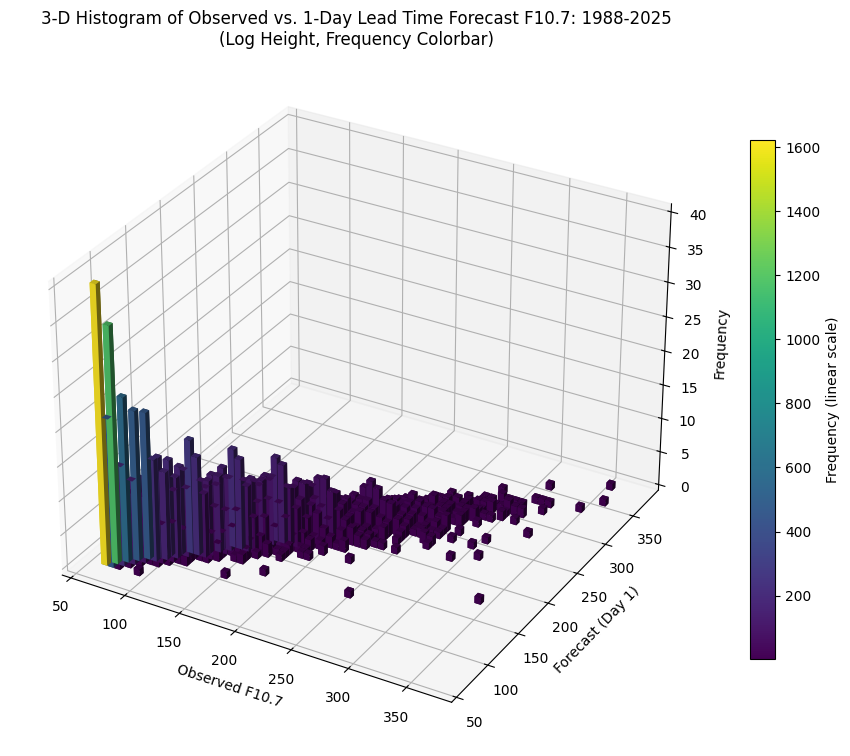

In [29]:
plot_3d_histogram(df_acc, obs_col="observed_day1", fcst_col="forecast_day1", sqrt_height=True, bins=50)

In [32]:
def plot_f107_heatmap(
        df_acc,
        obs_col="observed_day1",
        fcst_col="forecast_day1",
        bins=40,
        metric="frequency",   # "frequency", "absolute_error", "bias"
        leadtime="1-day",       # lead time for title
        cmap=None
    ):
    """
    Unified 2-D heatmap for F10.7 forecast accuracy.
    """

    obs = df_acc[obs_col].values
    fcst = df_acc[fcst_col].values

    # Default colormaps based on metric
    if cmap is None:
        if metric == "frequency":
            cmap = "viridis"
        elif metric == "absolute_error":
            cmap = "viridis"
        elif metric == "bias":
            cmap = "coolwarm"

    # Bin edges
    xedges = np.linspace(obs.min(), obs.max(), bins + 1)
    yedges = np.linspace(fcst.min(), fcst.max(), bins + 1)

    # Create base grids
    heatmap = np.zeros((bins, bins))
    counts = np.zeros((bins, bins))

    # Assign each point to bin
    xi = np.digitize(obs, xedges) - 1
    yi = np.digitize(fcst, yedges) - 1

    # Compute metrics
    if metric == "frequency":
        for o, f in zip(xi, yi):
            if 0 <= o < bins and 0 <= f < bins:
                heatmap[o, f] += 1

    elif metric == "absolute_error":
        errors = np.abs(fcst - obs)
        for o, f, e in zip(xi, yi, errors):
            if 0 <= o < bins and 0 <= f < bins:
                heatmap[o, f] += e
                counts[o, f] += 1
        heatmap = np.divide(heatmap, counts,
                            out=np.full_like(heatmap, np.nan),  # <-- fill empty bins with NaN
                            where=counts > 0)
        
    elif metric == "bias":
        bias = fcst - obs
        for o, f, b in zip(xi, yi, bias):
            if 0 <= o < bins and 0 <= f < bins:
                heatmap[o, f] += b
                counts[o, f] += 1
        heatmap = np.divide(heatmap, counts,
                            out=np.full_like(heatmap, np.nan),  # <-- fill empty bins with NaN
                            where=counts > 0)

    # ======= Plotting =======

    plt.figure(figsize=(10, 8))

    if metric == "frequency":
        # Log scaling for frequency maps
        norm = LogNorm(vmin=max(1, heatmap[heatmap>0].min()),
                       vmax=heatmap.max())
    elif metric == "bias":
        # Center color scale at zero (diverging)
        max_abs = np.nanmax(np.abs(heatmap))
        norm = TwoSlopeNorm(vmin=-max_abs, vcenter=0, vmax=max_abs)
    else:
        # Linear for absolute error
        norm = None

    img = plt.imshow(
        heatmap.T,
        origin='lower',
        cmap=cmap,
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        aspect='auto',
        norm=norm
    )

    # Colorbar
    cbar = plt.colorbar(img)
    if metric == "frequency":
        cbar.set_label("Frequency (log scale)")
    elif metric == "absolute_error":
        cbar.set_label("Mean Absolute Error")
    else:
        cbar.set_label("Bias (Forecast − Observed)")

    # Identity line (observed = forecast)
    #line_min = min(obs.min(), fcst.min())
    #line_max = max(obs.max(), fcst.max())
    line_min = 0
    line_max = 400
    plt.plot([line_min, line_max],
             [line_min, line_max],
             color="black", lw=1, label="Identity line")

    plt.xlabel("Observed F10.7")
    plt.ylabel("Forecast F10.7")
    plt.title(f"SWPC {leadtime} lead-time F10.7 Forecast Accuracy Heatmap ({metric})\n"
              f"Years 1988-2025")
    plt.legend(loc="upper left")

    # Compute metrics
    mae = np.mean(np.abs(fcst - obs))
    rmse = np.sqrt(np.mean((fcst - obs)**2))
    r, _ = pearsonr(obs, fcst)

    # --- Format metrics text ---
    metrics_text = (
        f"Overall MAE  = {mae:.2f}\n"
        f"Overall RMSE = {rmse:.2f}\n"
        f"Correlation = {r:.3f}"
)

    # --- Add text box to current axes ---
    plt.gca().text(
        0.02, 0.94,                 # position (top-left)
        metrics_text,
        transform=plt.gca().transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(
            boxstyle="square",
            facecolor="white",
            alpha=0.85,
            edgecolor="black"
    )
)

    plt.tight_layout()
    plt.savefig(f"verification_paper_figures/SWPC_day1_heatmap_{leadtime}_{metric}.png", dpi=300)
    plt.show()


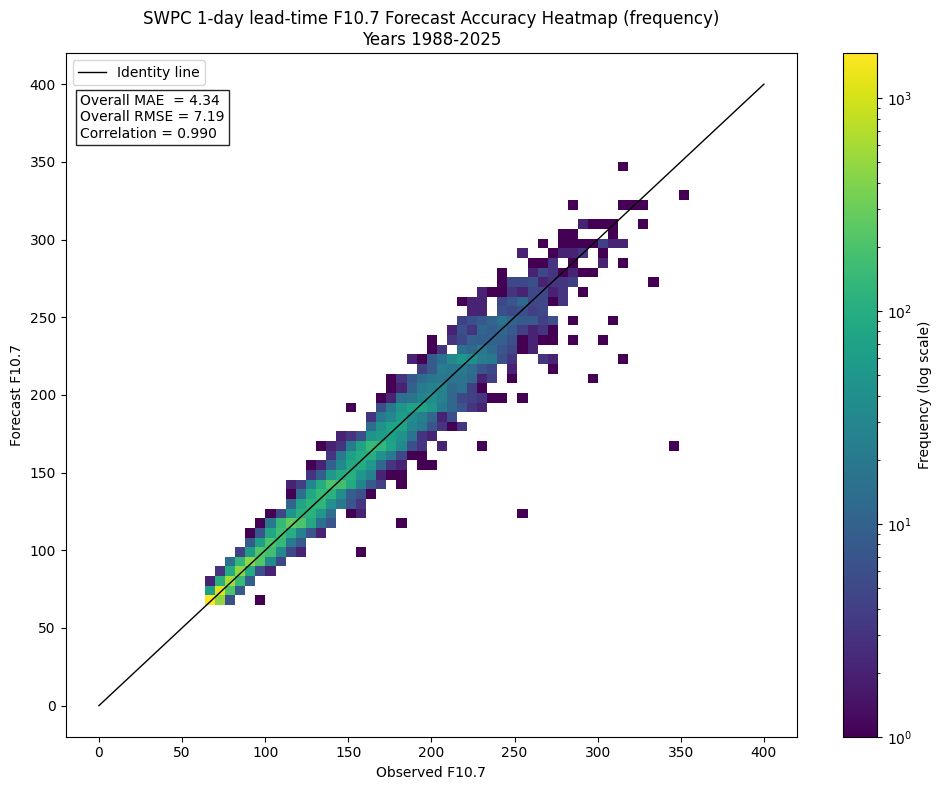

In [35]:
plot_f107_heatmap(df_acc, obs_col="observed_day1", fcst_col="forecast_day1", metric="frequency", leadtime="1-day", bins=50)

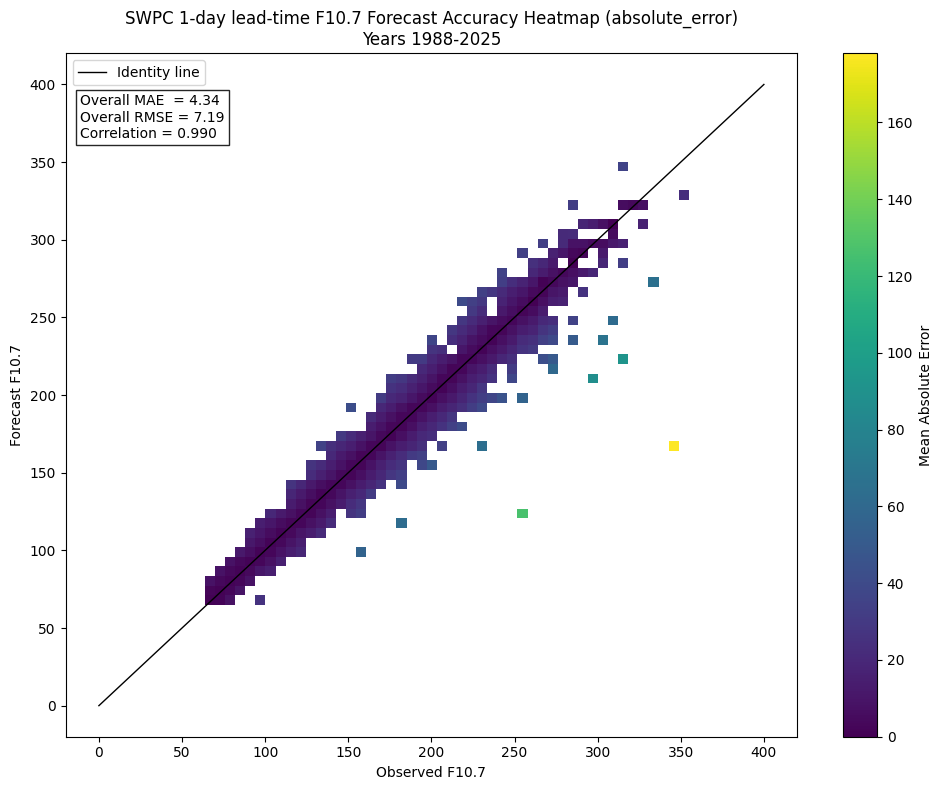

In [36]:
plot_f107_heatmap(df_acc, obs_col="observed_day1", fcst_col="forecast_day1", metric="absolute_error", leadtime="1-day", bins=50)

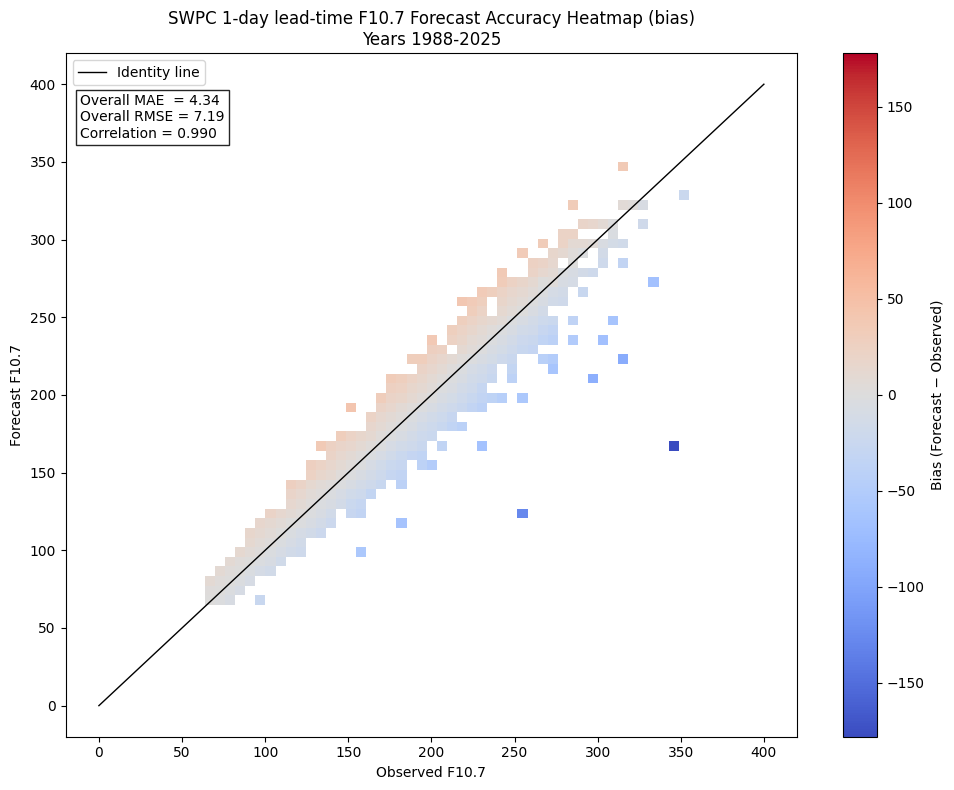

In [37]:
plot_f107_heatmap(df_acc, obs_col="observed_day1", fcst_col="forecast_day1", metric="bias", leadtime="1-day", bins=50)

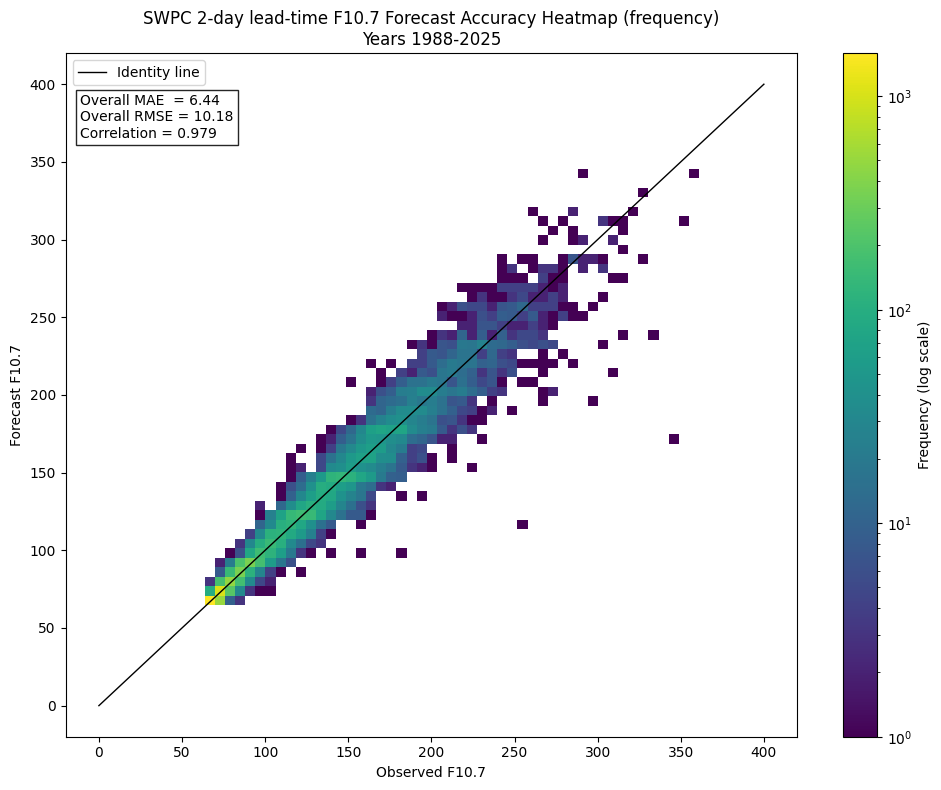

In [38]:
plot_f107_heatmap(df_acc, obs_col="observed_day2", fcst_col="forecast_day2", metric="frequency", leadtime="2-day", bins=50)

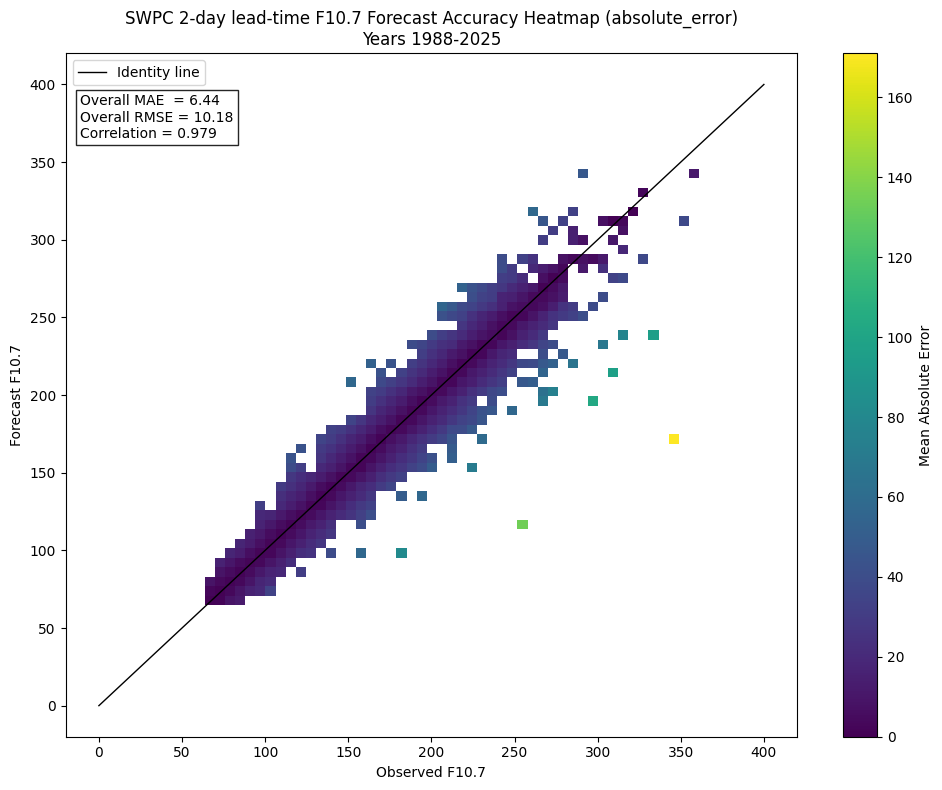

In [39]:
plot_f107_heatmap(df_acc, obs_col="observed_day2", fcst_col="forecast_day2", metric="absolute_error", leadtime="2-day", bins=50)

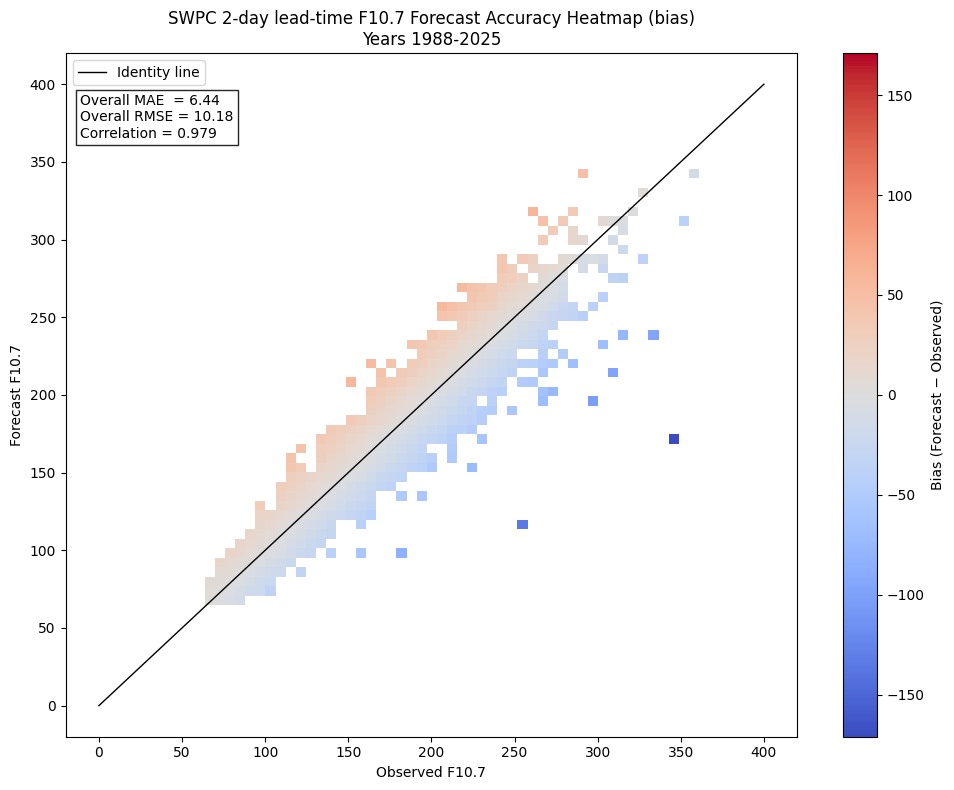

In [40]:
plot_f107_heatmap(df_acc, obs_col="observed_day2", fcst_col="forecast_day2", metric="bias", leadtime="2-day", bins=50)

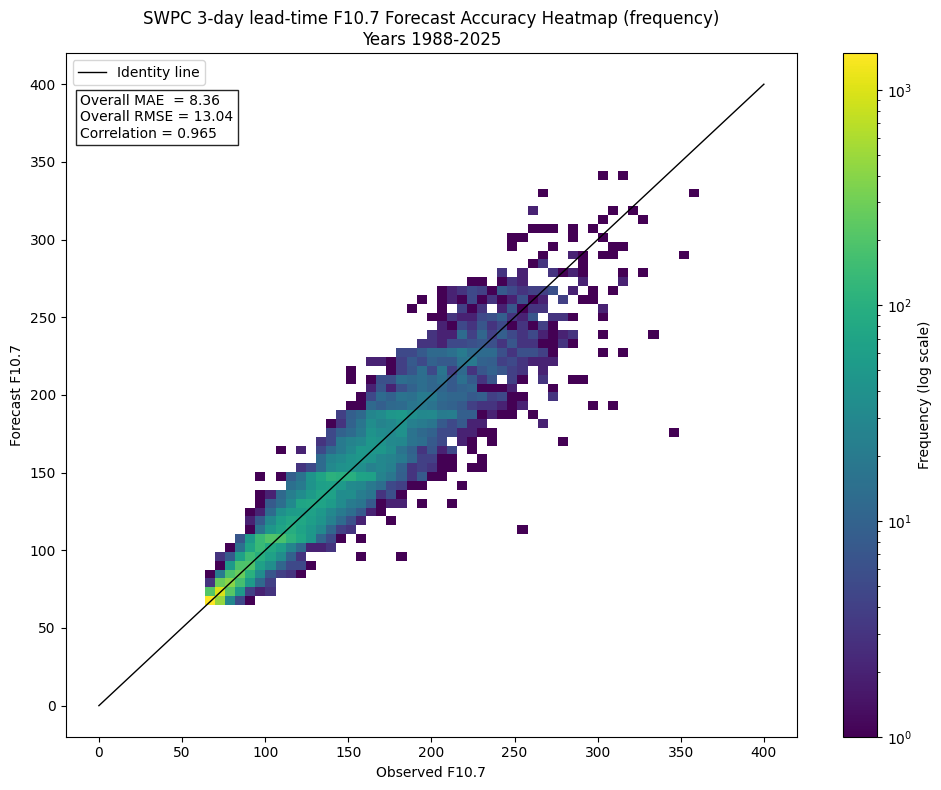

In [41]:
plot_f107_heatmap(df_acc, obs_col="observed_day3", fcst_col="forecast_day3", metric="frequency", leadtime="3-day", bins=50)

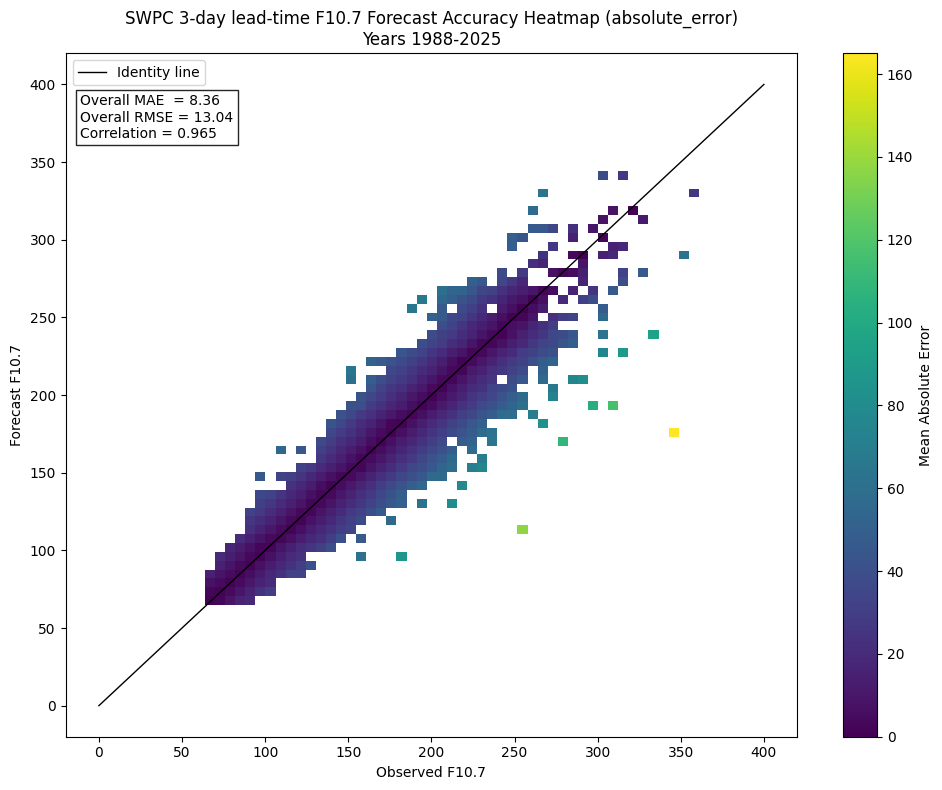

In [42]:
plot_f107_heatmap(df_acc, obs_col="observed_day3", fcst_col="forecast_day3", metric="absolute_error", leadtime="3-day", bins=50)

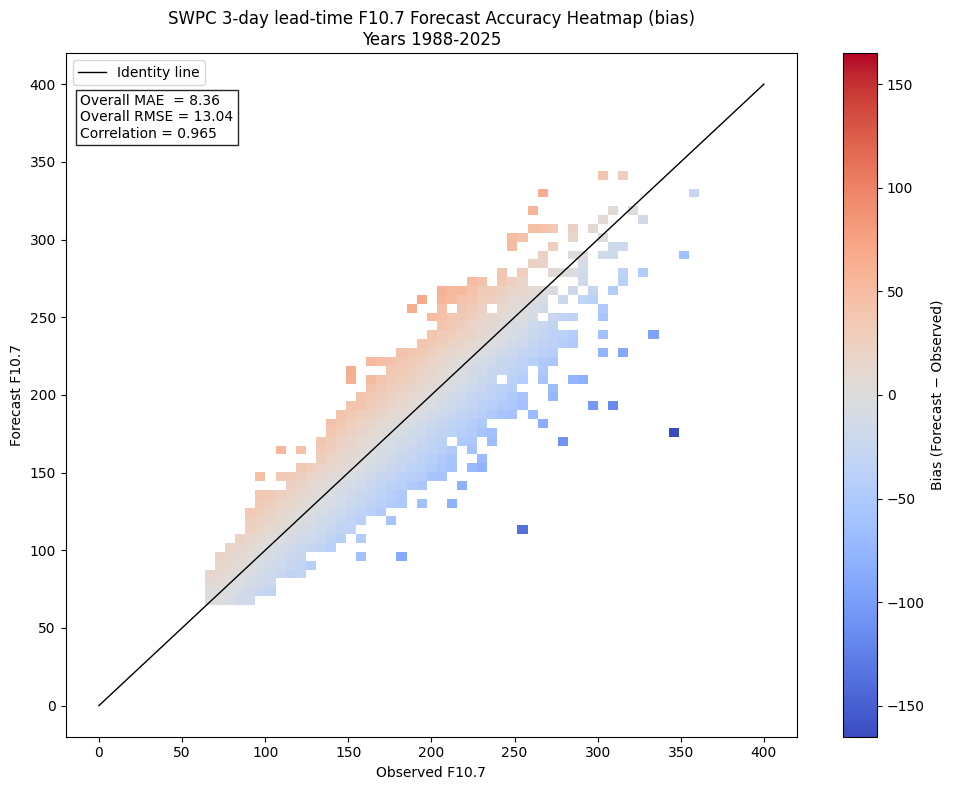

In [43]:
plot_f107_heatmap(df_acc, obs_col="observed_day3", fcst_col="forecast_day3", metric="bias", leadtime="3-day", bins=50)

#### scatter plot of forecast error vs. observed F10.7 values

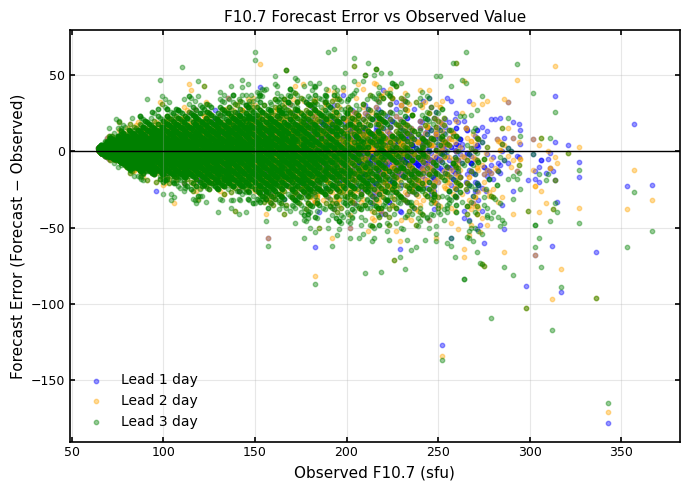

In [160]:
# ----------------------------
# Styling for AGU Space Weather publication
# ----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.top": True,
    "ytick.right": True,
    "legend.frameon": False,
    "pdf.fonttype": 42,   # Editable text in Illustrator
    "ps.fonttype": 42
})

leads = [1,2,3]

plt.figure(figsize=(7,5))

colors = {1:'blue', 2:'orange', 3:'green'}

for lead in leads:

    obs = df_acc[f'observed_day{lead}']
    fcst = df_acc[f'forecast_day{lead}']

    mask = (~obs.isna()) & (~fcst.isna())

    obs = obs[mask]
    fcst = fcst[mask]

    error = fcst - obs

    plt.scatter(
        obs,
        error,
        s=10,
        alpha=0.4,
        color=colors[lead],
        label=f'Lead {lead} day'
    )

plt.axhline(0, color='black', linewidth=1)

plt.xlabel("Observed F10.7 (sfu)")
plt.ylabel("Forecast Error (Forecast − Observed)")

plt.title("F10.7 Forecast Error vs Observed Value")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Forecast error by leadtime vs. observed F10.7 with conditional bias curves included

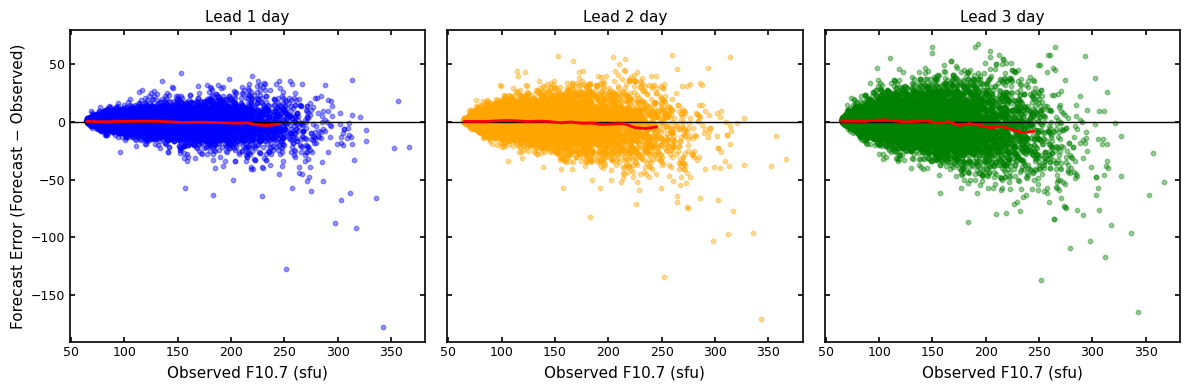

In [169]:
# ----------------------------
# Styling for AGU Space Weather publication
# ----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.top": True,
    "ytick.right": True,
    "legend.frameon": False,
    "pdf.fonttype": 42,   # Editable text in Illustrator
    "ps.fonttype": 42
})

leads = [1,2,3]
colors = {1:'blue', 2:'orange', 3:'green'}

bins = np.arange(60,260,10)

fig, axes = plt.subplots(1,3, figsize=(12,4), sharey=True)

for i, lead in enumerate(leads):

    obs = df_acc[f'observed_day{lead}']
    fcst = df_acc[f'forecast_day{lead}']

    mask = (~obs.isna()) & (~fcst.isna())

    obs = obs[mask]
    fcst = fcst[mask]

    error = fcst - obs

    df = pd.DataFrame({'obs':obs,'error':error})
    df['bin'] = pd.cut(df['obs'], bins)

    mean_err = df.groupby('bin')['error'].mean()

    centers = [b.mid for b in mean_err.index]

    hb = axes[i].scatter(
        obs,
        error,
        s=10,
        alpha=0.4,
        color=colors[lead],
        label=f'Lead {lead} day'
    )

    axes[i].axhline(0, color='black', linewidth=1)

    axes[i].set_title(f"Lead {lead} day")
    axes[i].set_xlabel("Observed F10.7 (sfu)")

    axes[i].plot(centers, mean_err, color='red', linewidth=2)


axes[0].set_ylabel("Forecast Error (Forecast − Observed)")

#fig.colorbar(hb, ax=axes.ravel().tolist(), label="Counts")

#plt.suptitle("Forecast Error vs Observed F10.7 (2-D Density)")

plt.tight_layout()
plt.savefig("verification_paper_figures/SWPC_F10.7_forecast_error_vs_observed.png", dpi=300)
plt.show()

#### Conditional bias curves alone. Not very interesting...

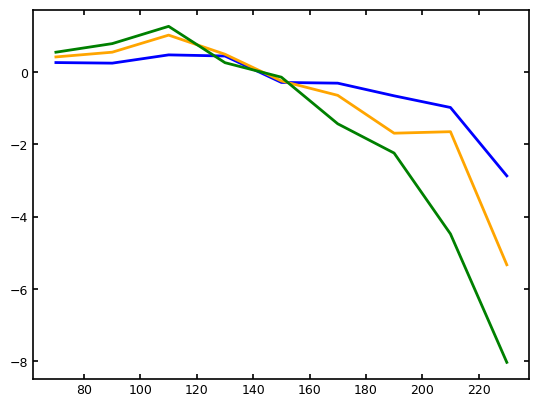

In [162]:


bins = np.arange(60, 260, 20)

for lead in leads:

    obs = df_acc[f'observed_day{lead}']
    fcst = df_acc[f'forecast_day{lead}']

    error = fcst - obs

    df = pd.DataFrame({'obs':obs, 'error':error})
    df['bin'] = pd.cut(df['obs'], bins)

    mean_error = df.groupby('bin')['error'].mean()
    centers = [b.mid for b in mean_error.index]

    plt.plot(centers, mean_error,
             linewidth=2,
             color=colors[lead])

#### Histograms of errors for each lead time

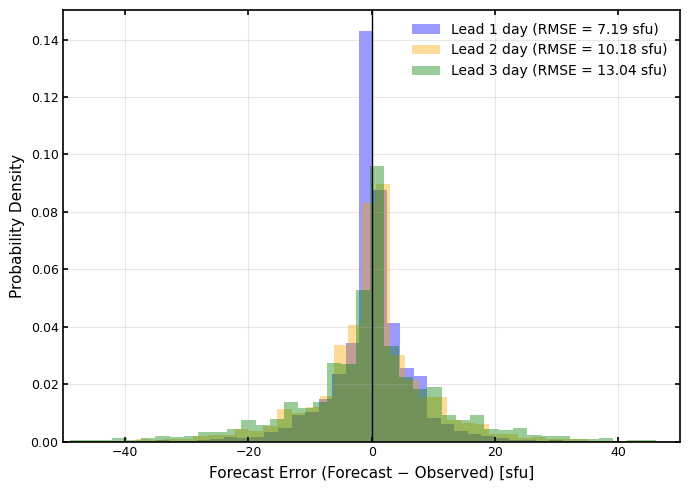

In [213]:
# ----------------------------
# Styling for AGU Space Weather publication
# ----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.top": True,
    "ytick.right": True,
    "legend.frameon": False,
    "pdf.fonttype": 42,   # Editable text in Illustrator
    "ps.fonttype": 42
})


leads = [1,2,3]
colors = {1:'blue', 2:'orange', 3:'green'}
alfa = {1:0.4, 2:0.4, 3:0.4}

plt.figure(figsize=(7,5))

for lead in leads:

    obs = df_acc[f'observed_day{lead}']
    fcst = df_acc[f'forecast_day{lead}']

    mask = (~obs.isna()) & (~fcst.isna())

    error = (fcst - obs)[mask]
    mean_err = np.mean(error)
    rmse = np.sqrt(np.mean(error**2))

    plt.hist(
        error,
        bins=100,
        density=True,
        alpha=alfa[lead],
        color=colors[lead],
        label=f"Lead {lead} day (RMSE = {rmse:.2f} sfu)"
    )

plt.axvline(0, color='black', linewidth=1)
plt.xlim(-50,50)

plt.xlabel("Forecast Error (Forecast − Observed) [sfu]")
plt.ylabel("Probability Density")

#plt.title("Distribution of F10.7 Forecast Errors")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("verification_paper_figures/SWPC_F10.7_forecast_error_histogram.png", dpi=300)
plt.show()

#### Conditional IQR errors of SWPC, persistence, 27-day recurrence vs. observed F10.7 binned in 5 sfu

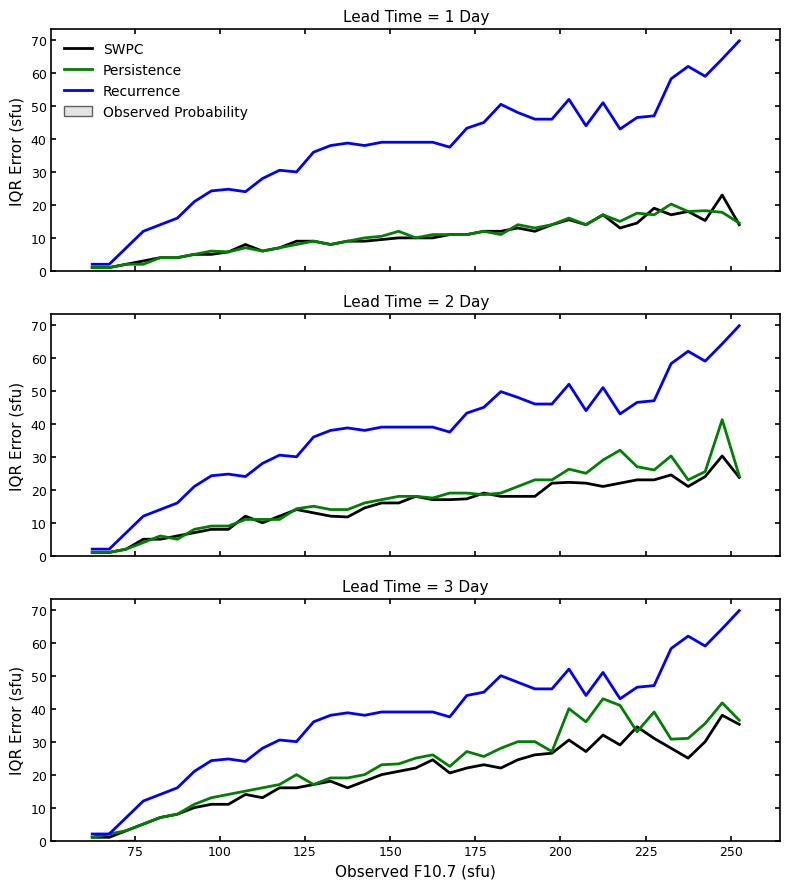

In [232]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------
# Configuration
# -----------------------------------------

leads = [1,2,3]
methods = {
    "SWPC": "forecast_day",
    "Persistence": "persistence_day",
    "Recurrence": "recurrence_day"
}

colors = {
    "SWPC": "black",
    "Persistence": "green",
    "Recurrence": "blue"
}

# F10.7 bins
bins = np.arange(60, 260, 5)

# -----------------------------------------
# Observed probability distribution
# -----------------------------------------

obs_all = df_acc["observed"]

prob_counts, bin_edges = np.histogram(obs_all, bins=bins, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# -----------------------------------------
# Create figure
# -----------------------------------------

fig, axes = plt.subplots(3,1, figsize=(8,9), sharex=True)

# -----------------------------------------
# Loop over lead times
# -----------------------------------------

for i, lead in enumerate(leads):

    ax = axes[i]

    # --- Plot probability bars ---
    ax.bar(
        bin_centers,
        prob_counts,
        width=4.5,
        color="lightgray",
        edgecolor="black",
        alpha=0.6,
        label="Observed Probability"
    )

    # --- Compute IQR curves ---
    for method, prefix in methods.items():

        obs = df_acc[f'observed_day{lead}']
        fcst = df_acc[f'{prefix}{lead}']

        mask = (~obs.isna()) & (~fcst.isna())

        obs = obs[mask]
        fcst = fcst[mask]

        error = fcst - obs

        df = pd.DataFrame({
            "obs": obs,
            "error": error
        })

        df["bin"] = pd.cut(df["obs"], bins)

        q75 = df.groupby("bin")["error"].quantile(0.75)
        q25 = df.groupby("bin")["error"].quantile(0.25)

        iqr = q75 - q25

        centers = [b.mid for b in q75.index]

        ax.plot(
            centers,
            iqr,
            color=colors[method],
            linewidth=2,
            label=method
        )

    ax.set_ylabel("IQR Error (sfu)")
    ax.set_title(f"Lead Time = {lead} Day")

    if i == 0:
        ax.legend()

axes[-1].set_xlabel("Observed F10.7 (sfu)")

plt.tight_layout()
plt.show()

### Forecast skill plots for various time ranges and solar cycle phases

#### Average skill over the entire 1988-2025 period:

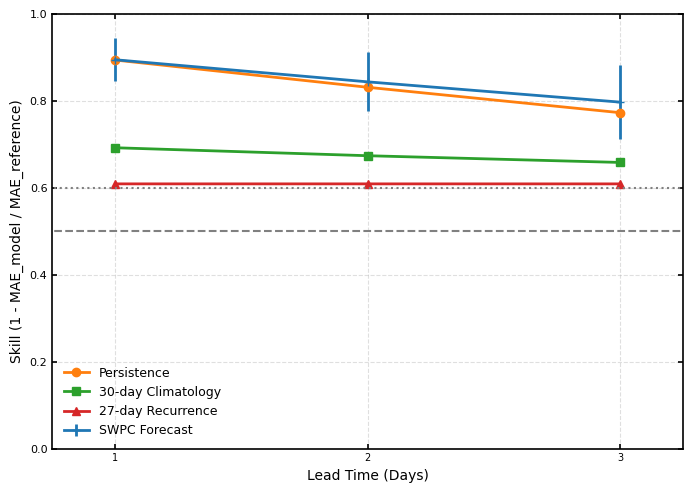

In [ ]:
# forecast skill vs. lead-time plot for the entire 1988-2025 period, using mean of observed over full periodas reference forecast for skill score calculations, as in SWPC verfication report from 2013. Also plot persistence, climatology, and recurrence skill for comparison.

leadtimes = [1, 2, 3] #days
skill_swpc = np.array([
    forecast_metrics_all[f"skill_day{lt}_swpc"]
    for lt in leadtimes
]).astype(float)

skill_swpc_std = np.array([
    forecast_metrics_all[f"mae_day{lt}_std"]
    for lt in leadtimes
]).astype(float)
skill_per = [forecast_metrics_all[f"skill_day{lt}_persistence"] for lt in leadtimes]
skill_clim = [forecast_metrics_all[f"skill_day{lt}_climatology"] for lt in leadtimes]
skill_rec  = [forecast_metrics_all[f"skill_day{lt}_recurrence"] for lt in leadtimes]

# --- Create figure ---
plt.figure(figsize=(7,5))

# Plot persistence skill
plt.errorbar(
    leadtimes, skill_swpc.flatten(),
    yerr = skill_swpc_std.flatten(),
    marker='+',
    linewidth=2,
    label='SWPC Forecast'
)
plt.plot(
    leadtimes, skill_per,
    marker='o',
    linewidth=2,
    label='Persistence'
)

# Plot climatology skill
plt.plot(
    leadtimes, skill_clim,
    marker='s',
    linewidth=2,
    label='30-day Climatology'
)

# Plot recurrence skill
plt.plot(
    leadtimes, skill_rec,
    marker='^',
    linewidth=2,
    label='27-day Recurrence'
)

#Typical skill thresholds for useful forecasts. Tropospheric forecast threshold is usually considered to 0.6. ITM system might be more tolerant of lower skill, but 0.5 is a common "no skill" threshold in many contexts.
plt.plot([0, 3.25],[0.5,0.5], color="gray", linestyle="--")
plt.plot([0, 3.25],[0.6,0.6], color="gray", linestyle=":")

# Formatting
plt.xlabel("Lead Time (Days)")
plt.ylabel("Skill (1 - MAE_model / MAE_reference)")
#plt.title("SWPC F10.7 Forecast Skill vs. Lead Time: 1988-2025" + "\n" + "Reference = Mean of Observed 1988-2025")
plt.xticks(leadtimes)
plt.ylim(0,1)
plt.xlim(0.75,3.25)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()

plt.tight_layout()
plt.savefig("verification_paper_figures/all_forecasts_skill_vs_lead_time_allref.png", dpi=300)
plt.show()


In [68]:
print(skill_swpc.flatten())
print(skill_swpc_std)

for x in skill_swpc_std:
    print(type(x), np.shape(x))

[0.89468906 0.84388136 0.79725029]
[[0.04926099]
 [0.06779581]
 [0.08602679]]
<class 'numpy.ndarray'> (1,)
<class 'numpy.ndarray'> (1,)
<class 'numpy.ndarray'> (1,)


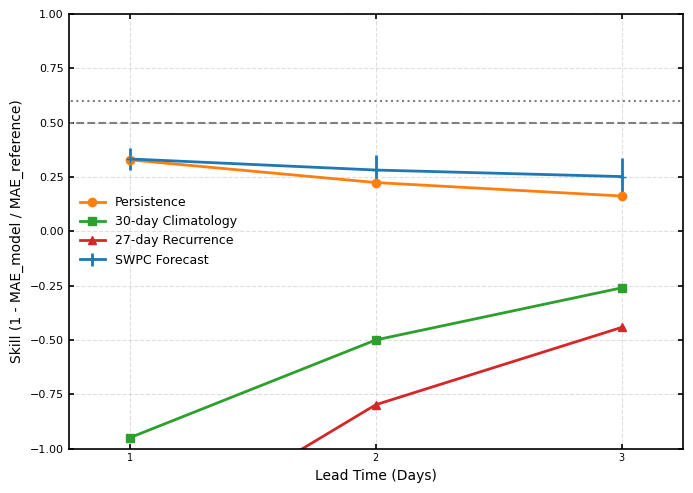

In [ ]:
# forecast skill vs. lead-time plot for the entire 1988-2025 period, using 3-day running mean of observed as reference forecast for skill score calculations.

leadtimes = [1, 2, 3] #days
skill_swpc = np.array([
    forecast_metrics_3d[f"skill_day{lt}_swpc"]
    for lt in leadtimes
]).astype(float)
skill_swpc_std = np.array([
    forecast_metrics_3d[f"mae_day{lt}_std"]
    for lt in leadtimes
]).astype(float)
skill_per = [forecast_metrics_3d[f"skill_day{lt}_persistence"] for lt in leadtimes]
skill_clim = [forecast_metrics_3d[f"skill_day{lt}_climatology"] for lt in leadtimes]
skill_rec  = [forecast_metrics_3d[f"skill_day{lt}_recurrence"] for lt in leadtimes]
              
# --- Create figure ---
plt.figure(figsize=(7,5))

# Plot persistence skill
plt.errorbar(
    leadtimes, skill_swpc.flatten(),
    yerr = skill_swpc_std.flatten(),
    marker='+',
    linewidth=2,
    label='SWPC Forecast'
)
plt.plot(
    leadtimes, skill_per,
    marker='o',
    linewidth=2,
    label='Persistence'
)

# Plot climatology skill
plt.plot(
    leadtimes, skill_clim,
    marker='s',
    linewidth=2,
    label='30-day Climatology'
)

# Plot recurrence skill
plt.plot(
    leadtimes, skill_rec,
    marker='^',
    linewidth=2,
    label='27-day Recurrence'
)

#Typical skill thresholds for useful forecasts. Tropospheric forecast threshold is usually considered to 0.6. ITM system might be more tolerant of lower skill, but 0.5 is a common "no skill" threshold in many contexts.
plt.plot([0, 3.25],[0.5,0.5], color="gray", linestyle="--")
plt.plot([0, 3.25],[0.6,0.6], color="gray", linestyle=":")

# Formatting
plt.xlabel("Lead Time (Days)")
plt.ylabel("Skill (1 - MAE_model / MAE_reference)")
#plt.title("SWPC F10.7 Forecast Skill vs. Lead Time: 1988-2025" + "\n" + "Reference = 3-Day Running Mean of Observed")
plt.xticks(leadtimes)
plt.ylim(-1,1)
plt.xlim(0.75,3.25)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()

plt.tight_layout()
plt.savefig("verification_paper_figures/all_forecasts_skill_vs_lead_time_3dref.png", dpi=300)
plt.show()


Analyze skill by year and by phase of solar cycle

In [48]:
df_acc

,issued_date,observed,forecast_day1,forecast_day2,forecast_day3,observed_day1,observed_day2,observed_day3,err_day1,err_day2,...,persistence_day2,persistence_day3,climatology_day1,climatology_day2,climatology_day3,recurrence_day1,recurrence_day2,recurrence_day3,3-day mean reference,year
0,1988-06-28,178.0,185.0,180.0,175.0,183.0,184.0,193.0,2.0,-4.0,...,178.0,178.0,137.035714,135.518519,134.769231,150.0,144.0,145.0,162.666667,1988
1,1988-06-29,183.0,185.0,180.0,170.0,184.0,193.0,192.0,1.0,-13.0,...,183.0,183.0,138.620690,137.035714,135.518519,144.0,145.0,147.0,172.000000,1988
2,1988-06-30,184.0,184.0,184.0,183.0,193.0,192.0,187.0,-9.0,-8.0,...,184.0,184.0,140.133333,138.620690,137.035714,145.0,147.0,147.0,181.666667,1988
3,1988-07-01,193.0,194.0,194.0,193.0,192.0,187.0,175.0,2.0,7.0,...,193.0,193.0,141.566667,140.133333,138.620690,147.0,147.0,154.0,186.666667,1988
4,1988-07-02,192.0,192.0,192.0,191.0,187.0,175.0,166.0,5.0,17.0,...,192.0,192.0,143.166667,141.566667,140.133333,147.0,154.0,160.0,189.666667,1988
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13546,2025-12-24,134.0,150.0,155.0,160.0,163.0,166.0,178.0,-13.0,-11.0,...,134.0,134.0,151.666667,151.066667,150.333333,120.0,138.0,160.0,136.333333,2025
13547,2025-12-25,163.0,165.0,170.0,175.0,166.0,178.0,188.0,-1.0,-8.0,...,163.0,163.0,153.233333,151.666667,151.066667,138.0,160.0,180.0,146.333333,2025
13548,2025-12-26,166.0,170.0,175.0,170.0,178.0,188.0,196.0,-8.0,-13.0,...,166.0,166.0,154.766667,153.233333,151.666667,160.0,180.0,196.0,154.333333,2025
13549,2025-12-27,178.0,175.0,170.0,160.0,188.0,196.0,182.0,-13.0,-26.0,...,178.0,178.0,156.700000,154.766667,153.233333,180.0,196.0,200.0,169.000000,2025


### Try to replicate skill vs. lead time plot in SWPC verification report. Time range = 1986-2013

#### The report plots skill of persistence, 30-day climatology, and recurrence forecasts in addition to skill of SWPC forecast. The skill metric used in the report is 'based on the relative error of the forecasts with respect to constant forecasts of sample climatology (the mean observation during the period) and is sometimes called the “prediction efficiency'.

In [49]:
years = range(1988, 2014)
results = []

for year in years:
    df_year = df_acc[df_acc["year"] == year]

    if len(df_year) == 0:
        continue

    swpc_skill = compute_swpc_skill(df_year,ref=df_year["observed"].mean())
    persistence_skill = compute_persistence_skill(df_year, ref=df_year["observed"].mean())
    climatology_skill  = compute_climatology_skill(df_year, ref=df_year["observed"].mean())
    recurrence_skill = compute_recurrence_skill(df_year, ref=df_year["observed"].mean())
    metrics            = compute_swpc_forecast_metrics(df_year)

    row = {"year": year}
    row.update(swpc_skill)
    row.update(persistence_skill)
    row.update(climatology_skill)
    row.update(recurrence_skill)
    row.update(metrics)
    results.append(row)

forecast_metrics_swpc_report= pd.DataFrame(results)


In [50]:
forecast_metrics_swpc_report 

,year,skill_day1_swpc,skill_day2_swpc,skill_day3_swpc,skill_day1_persistence,skill_day2_persistence,skill_day3_persistence,skill_day1_climatology,skill_day2_climatology,skill_day3_climatology,...,mae_day2,mae_day2_std,rmse_day2,rmse_day2_std,corr_day2,mae_day3,mae_day3_std,rmse_day3,rmse_day3_std,corr_day3
0,1988,0.702432,0.532651,0.404022,0.679192,0.503489,0.348909,0.060419,0.028400,0.007825,...,9.941176,0.600690,12.881816,4.502003,0.897409,12.721925,0.781292,16.594729,5.649992,0.829192
1,1989,0.652482,0.521564,0.368984,0.640827,0.460694,0.280925,0.029922,-0.021022,-0.062164,...,13.063712,0.592580,17.235858,5.259143,0.875258,17.229917,0.720698,21.996726,6.157435,0.793952
2,1990,0.752187,0.644556,0.520521,0.694851,0.482491,0.286608,0.012184,-0.037482,-0.082507,...,10.134615,0.455862,13.347120,3.865036,0.929556,13.678571,0.576113,17.538106,4.920481,0.876308
3,1991,0.712615,0.576036,0.439678,0.690437,0.499383,0.315087,0.070146,0.004775,-0.050149,...,13.736264,0.580987,17.641267,5.169710,0.907665,18.211538,0.751575,23.166917,6.536854,0.840348
4,1992,0.808900,0.698472,0.591501,0.795148,0.675005,0.564080,0.389256,0.351968,0.319787,...,9.786301,0.456239,13.097318,4.104904,0.951636,13.142466,0.588851,17.289874,5.254548,0.914134
5,1993,0.760161,0.634264,0.516419,0.770914,0.631004,0.498124,0.330118,0.292615,0.256980,...,6.454795,0.309425,8.747289,2.747200,0.919204,8.545205,0.409401,11.577139,3.527316,0.861332
6,1994,0.763603,0.634909,0.526384,0.783205,0.638771,0.520975,0.269372,0.217594,0.168548,...,3.395028,0.172454,4.718308,1.573151,0.929901,4.353591,0.219856,6.033516,2.008368,0.882541
7,1995,0.717728,0.581484,0.459699,0.730052,0.572106,0.415796,0.278025,0.242647,0.208865,...,2.664179,0.151565,3.637491,1.248054,0.884357,3.444030,0.175429,4.480888,1.407104,0.821466
8,1996,0.679964,0.531221,0.380949,0.687389,0.476158,0.302352,0.200528,0.140299,0.091760,...,1.754875,0.126678,2.970608,1.392334,0.861463,2.303621,0.170950,3.970995,1.871856,0.740940
9,1997,0.789641,0.699188,0.617400,0.816654,0.726405,0.658801,0.509123,0.479348,0.454091,...,2.908587,0.176618,4.437313,1.812013,0.932758,3.711911,0.221290,5.604213,2.223238,0.890831


#### Prediction efficiency plot for 1988-2013. Same as SWPC Verification report in order to verify their results.

In [148]:
# ---------------------------------------
# Prediction efficiency function
# ---------------------------------------
def prediction_efficiency(forecast, observation, climatology):
    numerator = np.sum((forecast - observation)**2)
    denominator = np.sum((observation - climatology)**2)
    return 1 - numerator / denominator


# ----------------------------
# Bootstrap
# ----------------------------
def bootstrap_pe(forecast, observation, climatology,
                 n_boot=2000, ci=95, seed=42):

    rng = np.random.default_rng(seed)

    mask = (~forecast.isna()) & (~observation.isna())
    f = forecast[mask].values
    o = observation[mask].values
    if isinstance(climatology, (pd.Series, np.ndarray)):
        climo = climatology[mask].values
    else:
        climo = climatology

    n = len(f)
    pe_samples = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        f_bs = f[idx]
        o_bs = o[idx]
        pe_bs = prediction_efficiency(f_bs, o_bs, climo)
        pe_samples.append(pe_bs)

    pe_samples = np.array(pe_samples)

    pe_mean = prediction_efficiency(f, o, climo)
    lower = np.percentile(pe_samples, (100-ci)/2)
    upper = np.percentile(pe_samples, 100-(100-ci)/2)

    return pe_mean, lower, upper


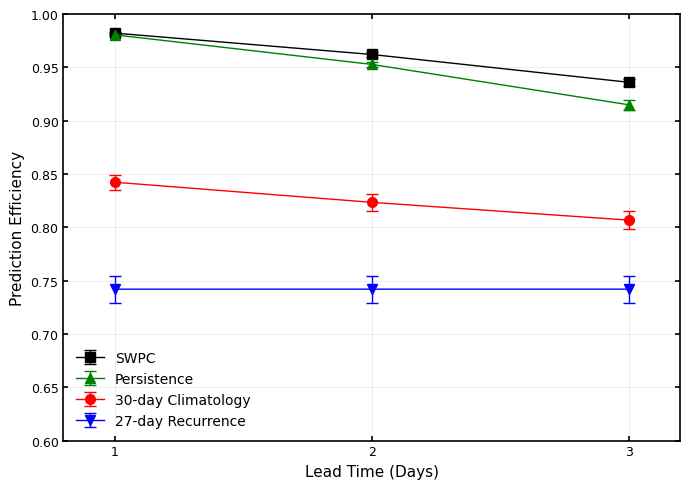

In [123]:
#Prediction efficiency with bootstrap confidence intervals for the 1988-2013 period, which overlaps with the period used in the SWPC verification report from 2014. 

# ----------------------------
# Styling for AGU Space Weather publication
# ----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.top": True,
    "ytick.right": True,
    "legend.frameon": False,
    "pdf.fonttype": 42,   # Editable text in Illustrator
    "ps.fonttype": 42
})
# ---------------------------------------
# Restrict to 1988–2013
# ---------------------------------------
df_acc['issued_date'] = pd.to_datetime(df_acc['issued_date'])
df_sel = df_acc[(df_acc['issued_date'].dt.year >= 1988) &
                (df_acc['issued_date'].dt.year <= 2013)].copy()

# ---------------------------------------
# Compute sample climatology
#    (mean observed over entire period)
# ---------------------------------------
all_obs = df_sel['observed'].dropna()
    

sample_climo = all_obs.mean()


# ----------------------------
# Compute results
# ----------------------------
leads = [1, 2, 3]

model_info = {
    "SWPC":        {"col": "forecast_day{}",     "color": "black", "marker": "s"},
    "Persistence": {"col": "persistence_day{}",  "color": "green", "marker": "^"},
    "30-day Climatology": {"col": "climatology_day{}",  "color": "red",   "marker": "o"},
    "27-day Recurrence":  {"col": "recurrence_day{}",   "color": "blue",  "marker": "v"},
}

results = {model: [] for model in model_info}

for lead in leads:

    obs = df_sel[f'observed_day{lead}']

    for model, info in model_info.items():
        forecast = df_sel[info["col"].format(lead)]
        pe_mean, lower, upper = bootstrap_pe(
            forecast,
            obs,
            sample_climo,
            n_boot=2000
        )
        results[model].append((pe_mean, lower, upper))


# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(7,5))

for model, info in model_info.items():

    pe_vals = np.array([r[0] for r in results[model]])
    lower   = np.array([r[1] for r in results[model]])
    upper   = np.array([r[2] for r in results[model]])

    err_low  = pe_vals - lower
    err_high = upper - pe_vals

    ax.errorbar(
        leads,
        pe_vals,
        yerr=[err_low, err_high],
        fmt=info["marker"],
        color=info["color"],
        markersize=7,
        capsize=4,
        linestyle='-',
        linewidth=1,
        label=model
    )

# Nominal skill reference
#ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)

# Axis formatting
ax.set_xlabel("Lead Time (Days)")
ax.set_ylabel("Prediction Efficiency")
ax.set_xticks(leads)
ax.set_xlim(0.8, 3.2)
ax.set_ylim(0.6, 1.0)
#ax.set_title("SWPC Prediction Efficiency (1988-2013)")

# Light background grid (AGU appropriate)
ax.grid(True, which='major', linestyle='-', linewidth=0.5, alpha=0.3)

ax.legend(loc='lower left')

plt.tight_layout()
plt.savefig("verification_paper_figures/prediction_efficiency_1988-2013.png", dpi=300)
plt.show()



In [113]:
sample_climo

np.float64(123.55570060922541)

#### Prediction efficiency over entire 1988-2025 period

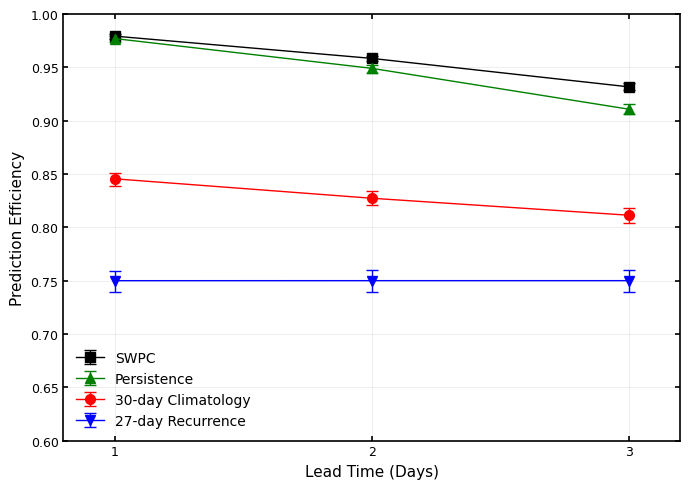

In [149]:
#Prediction efficiency with bootstrap confidence intervals for the entire 1988-2025 period. 

# ----------------------------
# Styling for AGU Space Weather publication
# ----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.top": True,
    "ytick.right": True,
    "legend.frameon": False,
    "pdf.fonttype": 42,   # Editable text in Illustrator
    "ps.fonttype": 42
})

# Use full dataset (1988-2025):
df_acc['issued_date'] = pd.to_datetime(df_acc['issued_date'])
df_sel = df_acc.copy()

# ---------------------------------------
# Compute sample climatology
#    (mean observed over entire period)
# ---------------------------------------
all_obs = df_sel['observed'].dropna()
    
sample_climo = all_obs.mean()

# ----------------------------
# Compute results
# ----------------------------
leads = [1, 2, 3]

model_info = {
    "SWPC":        {"col": "forecast_day{}",     "color": "black", "marker": "s"},
    "Persistence": {"col": "persistence_day{}",  "color": "green", "marker": "^"},
    "30-day Climatology": {"col": "climatology_day{}",  "color": "red",   "marker": "o"},
    "27-day Recurrence":  {"col": "recurrence_day{}",   "color": "blue",  "marker": "v"},
}

results = {model: [] for model in model_info}

for lead in leads:

    obs = df_sel[f'observed_day{lead}']

    for model, info in model_info.items():
        forecast = df_sel[info["col"].format(lead)]
        pe_mean, lower, upper = bootstrap_pe(
            forecast,
            obs,
            sample_climo,
            n_boot=2000
        )
        results[model].append((pe_mean, lower, upper))


# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(7,5))

for model, info in model_info.items():

    pe_vals = np.array([r[0] for r in results[model]])
    lower   = np.array([r[1] for r in results[model]])
    upper   = np.array([r[2] for r in results[model]])

    err_low  = pe_vals - lower
    err_high = upper - pe_vals

    ax.errorbar(
        leads,
        pe_vals,
        yerr=[err_low, err_high],
        fmt=info["marker"],
        color=info["color"],
        markersize=7,
        capsize=4,
        linestyle='-',
        linewidth=1,
        label=model
    )

# Nominal skill reference
#ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)

# Axis formatting
ax.set_xlabel("Lead Time (Days)")
ax.set_ylabel("Prediction Efficiency")
ax.set_xticks(leads)
ax.set_xlim(0.8, 3.2)
ax.set_ylim(0.6, 1.0)
#ax.set_title("SWPC Prediction Efficiency (1988-2025)")

# Light background grid (AGU appropriate)
ax.grid(True, which='major', linestyle='-', linewidth=0.5, alpha=0.3)

ax.legend(loc='lower left')

plt.tight_layout()
#plt.savefig("verification_paper_figures/prediction_efficiency_1988-2025.png", dpi=300)
plt.show()



In [106]:
sample_climo

np.float64(120.10648660615453)

#### There is no significant difference between this plot and the 1988-2013 plot: using entire period mean climatology and averaging all years masks a lot of skill variation. 

#### Repeat this plot with 30-day rolling average climatology as reference forecast for PE calculation

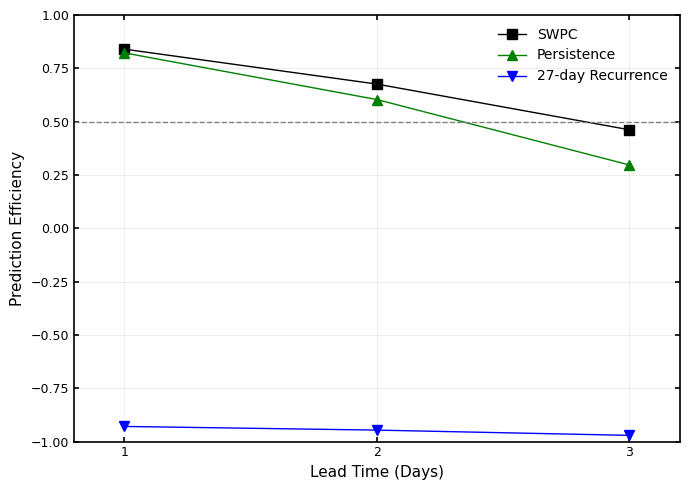

In [ ]:
#Prediction efficiency with bootstrap confidence intervals for the 1988-2025 period. 
#Sample climatology is now the 30-day running mean instead of the mean over the entire period. 
#Note that the yerr values were negative for some points when using the 30-day running mean as reference, which caused matplotlib to raise an error. 
#Just used normal ax.plot instead...

# ----------------------------
# Styling for AGU Space Weather publication
# ----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.top": True,
    "ytick.right": True,
    "legend.frameon": False,
    "pdf.fonttype": 42,   # Editable text in Illustrator
    "ps.fonttype": 42
})

# Use full dataset (1988-2025):
df_acc['issued_date'] = pd.to_datetime(df_acc['issued_date'])
df_sel = df_acc.copy()

# ---------------------------------------
# Compute sample climatology
#    (mean observed over 30-day rolling period)
# ---------------------------------------

    
# 30-day rolling climatology of observed values
df_sel['clim_30d'] = (
    df_sel['observed']
    .rolling(window=30, center=True, min_periods=15).mean() 
)   

# ----------------------------
# Compute results
# ----------------------------
leads = [1, 2, 3]

model_info = {
    "SWPC":        {"col": "forecast_day{}",     "color": "black", "marker": "s"},
    "Persistence": {"col": "persistence_day{}",  "color": "green", "marker": "^"},
    "27-day Recurrence":  {"col": "recurrence_day{}",   "color": "blue",  "marker": "v"},
}

results = {model: [] for model in model_info}

for lead in leads:

    obs = df_sel[f'observed_day{lead}']

    for model, info in model_info.items():
        forecast = df_sel[info["col"].format(lead)]
        pe_mean, lower, upper = bootstrap_pe(
            forecast,
            obs,
            df_sel['clim_30d'],
            n_boot=2000
        )
        results[model].append((pe_mean, lower, upper))


# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(7,5))

for model, info in model_info.items():

    pe_vals = np.array([r[0] for r in results[model]])
    lower   = np.array([r[1] for r in results[model]])
    upper   = np.array([r[2] for r in results[model]])

    err_low  = np.where(pe_vals - lower < 0, 0, pe_vals - lower)
    err_high = upper - pe_vals

    #ax.errorbar(
    #    leads,
    #    pe_vals,
    #    yerr=[err_low, err_high],
    #    fmt=info["marker"],
    #    color=info["color"],
    #   markersize=7,
    #    capsize=4,
    #    linestyle='-',
    #    linewidth=1,
    #    label=model
    #)

    ax.plot(
        leads, pe_vals,
        marker=info["marker"],
        color=info["color"],
        markersize=7,
        linestyle='-',
        linewidth=1,
        label=model
    )

# Nominal skill reference
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)

# Axis formatting
ax.set_xlabel("Lead Time (Days)")
ax.set_ylabel("Prediction Efficiency")
ax.set_xticks(leads)
ax.set_xlim(0.8, 3.2)
ax.set_ylim(-1.0, 1.0)
#ax.set_title("SWPC Prediction Efficiency (1988-2025)\n" + "Reference = 30-Day Rolling Mean of Observed")

# Light background grid (AGU appropriate)
ax.grid(True, which='major', linestyle='-', linewidth=0.5, alpha=0.3)

ax.legend(loc='best')

plt.tight_layout()
plt.savefig("verification_paper_figures/prediction_efficiency_30-day_ref_1988-2025.png", dpi=300)
plt.show()



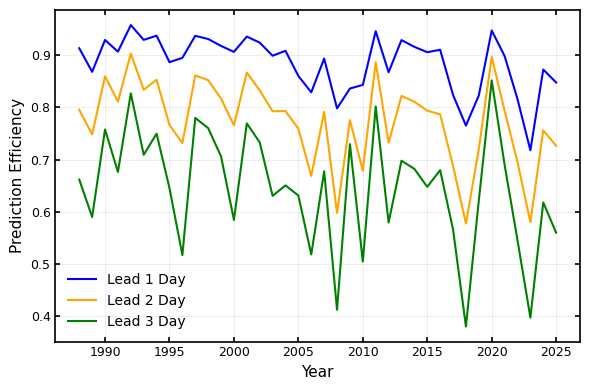

In [ ]:
#Annual prediction efficiency with bootstrap confidence intervals for the 1988-2025 period, 
# using 30-day running mean of observed as reference forecast for skill score calculations.

# ----------------------------
# Styling for AGU Space Weather publication
# ----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.top": True,
    "ytick.right": True,
    "legend.frameon": False,
    "pdf.fonttype": 42,   # Editable text in Illustrator
    "ps.fonttype": 42
})

df_acc['issued_date'] = pd.to_datetime(df_acc['issued_date'])
df_sel = df_acc.copy()


# 30-day rolling climatology of observed values
df_sel['clim_30d'] = (
    df_sel['observed']
    .rolling(window=30, center=True, min_periods=15)
    .mean()
)   

years = sorted(df_sel['year'].unique())
leads = [1, 2, 3]

annual_pe = {lead: [] for lead in leads}

for yr in years:

    df_year = df_sel[df_sel['year'] == yr]

    for lead in leads:

        f = df_year[f'forecast_day{lead}']
        o = df_year[f'observed_day{lead}']
        c = df_year['clim_30d']

        mask = (~f.isna()) & (~o.isna()) & (~c.isna())

        f = f[mask]
        o = o[mask]
        c = c[mask]

        pe_mean, lower, upper = bootstrap_pe(
            f,
            o,
            c.mean(),
            n_boot=2000
        )

        annual_pe[lead].append(pe_mean)



#plotting
plt.figure(figsize=(6,4))

colors = {1: "blue", 2: "orange", 3: "green"}

for lead in leads:
    plt.plot(years, annual_pe[lead],
             color=colors[lead],
             linewidth=1.5,
             label=f"Lead {lead} Day")

#plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.xlabel("Year")
plt.ylabel("Prediction Efficiency")
#plt.title("Annual Prediction Efficiency\n(30-Day Rolling Climatology)")
plt.legend()
plt.grid(True, linestyle='-', linewidth=0.5, alpha=0.3)

plt.tight_layout()
plt.savefig("verification_paper_figures/annual_prediction_efficiency_1988-2025.png", dpi=300)
plt.show()


#### Annual F10.7 statistics for 1988-2025. Same style as SWPC verification report.

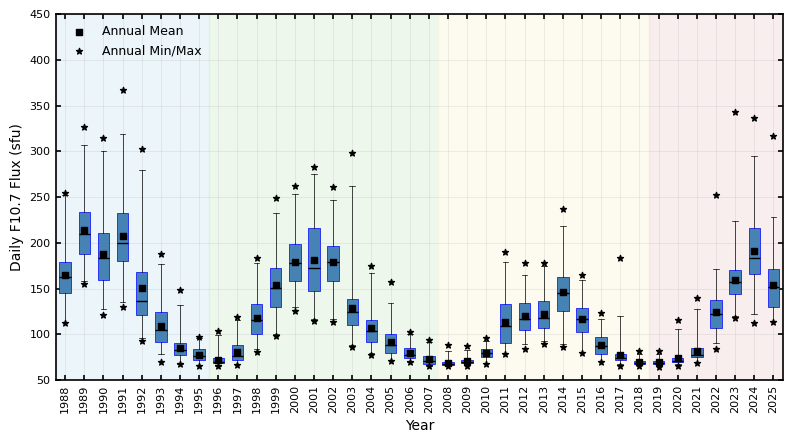

In [55]:


# -------------------------------------------------
# AGU / Space Weather styling
# -------------------------------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "legend.frameon": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

# -------------------------------------------------
# Prepare data
# -------------------------------------------------

df_valid = df_acc[['year', 'observed']].dropna()

grouped = df_valid.groupby('year')['observed']
years = sorted(grouped.groups.keys())

# -------------------------------------------------
# Solar cycle boundaries
# -------------------------------------------------
solar_cycles = [
    (1976, 1986, "Cycle 21", "#f0f0f0"),
    (1986, 1996, "Cycle 22", "#d9edf7"),
    (1996, 2008, "Cycle 23", "#dff0d8"),
    (2008, 2019, "Cycle 24", "#fcf8e3"),
    (2019, 2030, "Cycle 25", "#f2dede")
]

# -------------------------------------------------
# Compute box statistics
# -------------------------------------------------
box_data = []
means = []
mins = []
maxs = []

for yr in years:
    data = grouped.get_group(yr).values

    q1 = np.percentile(data, 25)
    median = np.percentile(data, 50)
    q3 = np.percentile(data, 75)
    p1 = np.percentile(data, 1)
    p99 = np.percentile(data, 99)

    box_data.append({
        'year': yr,
        'whislo': p1,
        'q1': q1,
        'med': median,
        'q3': q3,
        'whishi': p99,
        'fliers': []
    })

    means.append(np.mean(data))
    mins.append(np.min(data))
    maxs.append(np.max(data))

# -------------------------------------------------
# Plot
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4.5))

positions = np.arange(len(years))

# Background solar-cycle shading
for start, end, label, color in solar_cycles:
    idx = [i for i, y in enumerate(years) if start <= y < end]
    if idx:
        ax.axvspan(min(idx)-0.5, max(idx)+0.5,
                   color=color, alpha=0.5, zorder=0)

# Draw boxplot
bp = ax.bxp(
    box_data,
    positions=positions,
    widths=0.6,
    showfliers=False,
    patch_artist=True
)

# Style boxes
for box in bp['boxes']:
    box.set(facecolor='steelblue', edgecolor='blue', linewidth=0.5)

for median in bp['medians']:
    median.set(color='black', linewidth=1.0)

for whisker in bp['whiskers']:
    whisker.set(color='black', linewidth=0.5)

for cap in bp['caps']:
    cap.set(color='black', linewidth=0.5)

# Add annual mean (small square)
ax.scatter(positions, means,
           marker='s', s=20,
           color='black', zorder=3,
           label='Annual Mean')

# Add annual min/max (stars)
ax.scatter(positions, mins,
           marker='*', s=20,
           color='black', zorder=3,
           label='Annual Min/Max')

ax.scatter(positions, maxs,
           marker='*', s=20,
           color='black', zorder=3)

# -------------------------------------------------
# Axis formatting
# -------------------------------------------------
ax.set_xticks(positions)
ax.set_xticklabels(years, rotation=90)

ax.set_ylim(50, 450)

ax.set_xlabel("Year")
ax.set_ylabel("Daily F10.7 Flux (sfu)")
#ax.set_title("Annual Distribution of Daily F10.7 Solar Flux\nPenticton, Canada")

ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.3)

# Avoid duplicate legend entries
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), loc='upper left')

plt.tight_layout()
#plt.savefig("verification_paper_figures/F107_annual_boxplot_solarcycle_AGU.png", dpi=300)
plt.show()


#### Summary forecast statistics by year along with mean F10.7 bar chart. Same as in SWPC Verification report but with skill added as 5th panel. Note that skill is relative to 30-day mean climatology, not mean climatology over the entire dataset as in the report. It is pretty ridiculous to measure skill relative to a dumb average over all the data...

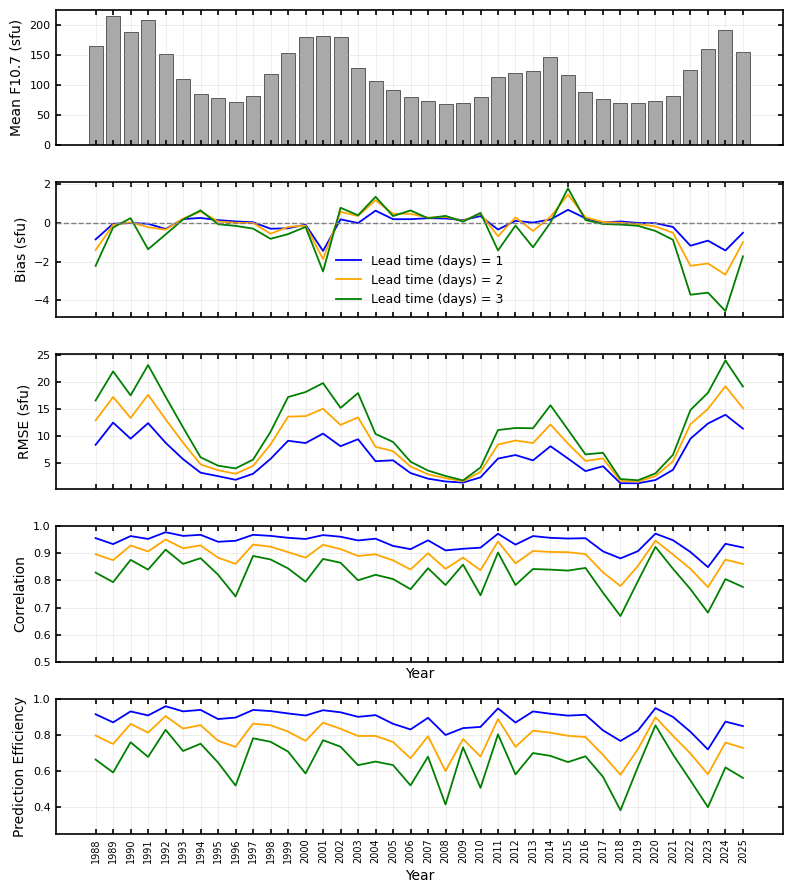

In [56]:

# -------------------------------------------------
# AGU / Space Weather styling
# -------------------------------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 7,
    "ytick.labelsize": 8,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "legend.frameon": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

# -------------------------------------------------
# Prepare data
# -------------------------------------------------
df_sel = df_acc.copy()


# 30-day rolling climatology of observed values
df_sel['clim_30d'] = (
    df_sel['observed']
    .rolling(window=30, center=True, min_periods=15)
    .mean()
)   

years = sorted(df_sel['year'].unique())
leads = [1, 2, 3]

annual_mean_obs = []
annual_bias = {lead: [] for lead in leads}
annual_rmse = {lead: [] for lead in leads}
annual_corr = {lead: [] for lead in leads}
annual_pe = {lead: [] for lead in leads}

# -------------------------------------------------
# Compute annual metrics
# -------------------------------------------------
for yr in years:

    df_year = df_sel[df_sel['year'] == yr]

    annual_mean_obs.append(df_year['observed'].mean())

    for lead in leads:

        f = df_year[f'forecast_day{lead}']
        o = df_year[f'observed_day{lead}']
        c = df_year['clim_30d']

        mask = (~f.isna()) & (~o.isna())
        f = f[mask]
        o = o[mask]
        c = c[mask]

        if len(f) > 0:
            error = f - o
            annual_bias[lead].append(np.mean(error))
            annual_rmse[lead].append(np.sqrt(np.mean(error**2)))
            annual_corr[lead].append(np.corrcoef(f, o)[0,1])
            pe_mean, _, _ = bootstrap_pe(f,o,c.mean(),n_boot=2000)
            annual_pe[lead].append(pe_mean)
        else:
            annual_bias[lead].append(np.nan)
            annual_rmse[lead].append(np.nan)
            annual_corr[lead].append(np.nan)
            annual_pe[lead].append(np.nan)
        
# -------------------------------------------------
# Plot
# -------------------------------------------------
fig, axes = plt.subplots(5, 1, figsize=(8, 9), sharex=True)

colors = {1: "blue", 2: "orange", 3: "green"}

# ---- Panel 1: Mean Observed (Bar Chart) ----
axes[0].bar(years, annual_mean_obs,
            color='darkgrey',
            edgecolor='black',
            linewidth=0.4)

axes[0].set_ylabel("Mean F10.7 (sfu)")
#axes[0].set_title("Annual Verification Metrics for SWPC F10.7 Forecasts")

# ---- Panel 2: Bias ----
for lead in leads:
    axes[1].plot(years, annual_bias[lead],
                 color=colors[lead],
                 linewidth=1.3,
                 label=f"Lead time (days) = {lead}")

axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[1].set_ylabel("Bias (sfu)")
axes[1].legend(loc="best")

# ---- Panel 3: RMSE ----
for lead in leads:
    axes[2].plot(years, annual_rmse[lead],
                 color=colors[lead],
                 linewidth=1.3)

axes[2].set_ylabel("RMSE (sfu)")

# ---- Panel 4: Correlation ----
for lead in leads:
    axes[3].plot(years, annual_corr[lead],
                 color=colors[lead],
                 linewidth=1.3)

axes[3].set_ylabel("Correlation")
axes[3].set_xlabel("Year")
axes[3].set_ylim(0.5, 1)

# ---- Panel 5: Prediction Efficiency ----
for lead in leads:
    axes[4].plot(years, annual_pe[lead],
                 color=colors[lead],
                 linewidth=1.3)         
axes[4].set_ylabel("Prediction Efficiency")
axes[4].set_xlabel("Year")
axes[4].set_ylim(0.25, 1.0)

# ---- X-axis: label every year ----
axes[4].set_xticks(years)
axes[4].set_xticklabels(years, rotation=90)

# ---- Light grid on all panels ----
for ax in axes:
    ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.3)

plt.tight_layout()
#plt.savefig("verification_paper_figures/F107_annual_verification_metrics_bar_AGU.png", dpi=300)
plt.show()

# Optional vector export
# plt.savefig("F107_annual_verification_AGU_bar_top.pdf",
#             dpi=600, bbox_inches="tight")

#### Add SWPC verification report 3-day lead time data from 1988-2013 as symbols on the bottom 4 plots

In [57]:
def parse_forecast_csv(filepath):

    results = []
    current_year = None

    with open(filepath, 'r', encoding='utf-8-sig') as f:
        lines = f.readlines()

    for line in lines:

        # Split row into columns
        parts = [p.strip() for p in line.strip().split(',')]

        if len(parts) == 0:
            continue

        label = parts[0]

        # ---- Extract year ----
        if label == "Year:":
            current_year = int(parts[1])
            continue

        # ---- Skip metadata rows ----
        if label in [
            "Start:", "End:", "Lead Time:",
            "Total Records:", "Forecast Type:"
        ]:
            continue

        # ---- Metric rows (end with :) ----
        if label.endswith(":"):

            metric = label.replace(":", "")

            values = parts[1:8]

            numeric_values = []
            for v in values:
                try:
                    numeric_values.append(float(v))
                except:
                    numeric_values.append(None)

            results.append(
                [current_year, metric] + numeric_values
            )

    df_final = pd.DataFrame(
        results,
        columns=["year", "metric"] + [f"day{i}" for i in range(1,8)]
    )

    return df_final


# ---- USE IT ----
swpc_verification_data = parse_forecast_csv("SWPC_1986-2013_verification_report_analysis/SWPC_F10.7_Solar_Flux.csv")


In [58]:
df_verif = swpc_verification_data.copy()
df_verif.head()

,year,metric,day1,day2,day3,day4,day5,day6,day7
0,2013,Mean (f),122.78,122.37,121.56,120.48,119.46,118.45,117.78
1,2013,Mean (x),122.75,122.75,122.75,122.75,122.75,122.75,122.75
2,2013,Median (f),118.00,120.00,120.00,120.00,115.00,115.00,115.00
3,2013,Median (x),118.00,118.00,118.00,118.00,118.00,118.00,118.00
4,2013,Std Dev (f),20.45,20.03,19.35,18.60,18.02,17.48,17.23


In [59]:
swpc_years = sorted(df_verif.loc[df_verif['year'] >= 1988, 'year'].unique())

# -------------------------------------------------
# Filter to years >= 1988 first
# -------------------------------------------------

bias_verif = df_verif[
    (df_verif['metric'] == 'ME') &
    (df_verif['year'] >= 1988)
].copy()

rmse_verif = df_verif[
    (df_verif['metric'] == 'RMSE') &
    (df_verif['year'] >= 1988)
].copy()

corr_verif = df_verif[
    (df_verif['metric'] == 'Linear Assoc') &
    (df_verif['year'] >= 1988)
].copy()

skill_verif = df_verif[
    (df_verif['metric'] == 'Skill') &
    (df_verif['year'] >= 1988)
].copy()

# Sort
bias_verif = bias_verif.sort_values('year')
rmse_verif = rmse_verif.sort_values('year')
corr_verif = corr_verif.sort_values('year')
skill_verif = skill_verif.sort_values('year')

# Set year as index for alignment
bias_verif = bias_verif.set_index('year')
rmse_verif = rmse_verif.set_index('year')
corr_verif = corr_verif.set_index('year')
skill_verif = skill_verif.set_index('year')

# -------------------------------------------------
# Align exactly to swpc_years
# -------------------------------------------------
bias_verif = bias_verif.reindex(swpc_years)
rmse_verif = rmse_verif.reindex(swpc_years)
corr_verif = corr_verif.reindex(swpc_years)
skill_verif = skill_verif.reindex(swpc_years)

# -------------------------------------------------
# Build dictionaries
# -------------------------------------------------
bias_verif_dict = {}
rmse_verif_dict = {}
corr_verif_dict = {}
skill_verif_dict = {}

for lead in leads:
    bias_verif_dict[lead] = bias_verif[f'day{lead}'].values 
    rmse_verif_dict[lead] = rmse_verif[f'day{lead}'].values
    corr_verif_dict[lead] = corr_verif[f'day{lead}'].values
    skill_verif_dict[lead] = skill_verif[f'day{lead}'].values

In [60]:
print(skill_verif_dict[2])

[0.9  0.75 0.83 0.81 0.91 0.83 0.87 0.76 0.73 0.86 0.85 0.82 0.78 0.87
 0.83 0.79 0.9  0.79 0.67 0.8  0.61 0.77 0.67 0.89 0.73 0.82]


In [61]:
print(len(swpc_years))
print(len(rmse_verif_dict[1]))

26
26


####  Add verification report points to metrics plots

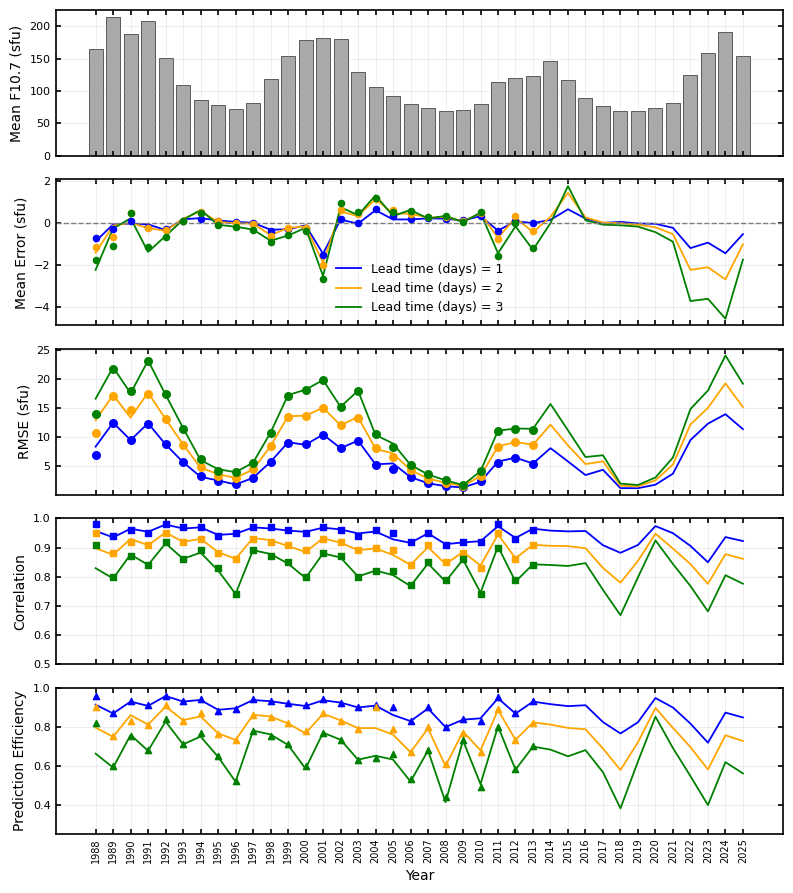

In [62]:

# -------------------------------------------------
# AGU / Space Weather styling
# -------------------------------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 7,
    "ytick.labelsize": 8,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "legend.frameon": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

# -------------------------------------------------
# Prepare data
# -------------------------------------------------

df_sel = df_acc.copy()

# 30-day rolling climatology of observed values
df_sel['clim_30d'] = (
    df_sel['observed']
    .rolling(window=30, center=True, min_periods=15)
    .mean()
)   

years = sorted(df_sel['year'].unique())
leads = [1, 2, 3]

annual_mean_obs = []
annual_bias = {lead: [] for lead in leads}
annual_rmse = {lead: [] for lead in leads}
annual_corr = {lead: [] for lead in leads}
annual_pe = {lead: [] for lead in leads}

# -------------------------------------------------
# Compute annual metrics
# -------------------------------------------------
for yr in years:

    df_year = df_sel[df_sel['year'] == yr]

    annual_mean_obs.append(df_year['observed'].mean())

    for lead in leads:

        f = df_year[f'forecast_day{lead}']
        o = df_year[f'observed_day{lead}']
        c = df_year['clim_30d']

        mask = (~f.isna()) & (~o.isna())
        f = f[mask]
        o = o[mask]
        c = c[mask]

        if len(f) > 0:
            error = f - o
            annual_bias[lead].append(np.mean(error))
            annual_rmse[lead].append(np.sqrt(np.mean(error**2)))
            annual_corr[lead].append(np.corrcoef(f, o)[0,1])
            pe_mean, _, _ = bootstrap_pe(f,o,c.mean(),n_boot=2000)
            annual_pe[lead].append(pe_mean)
        else:
            annual_bias[lead].append(np.nan)
            annual_rmse[lead].append(np.nan)
            annual_corr[lead].append(np.nan)
            annual_pe[lead].append(np.nan)
        
# -------------------------------------------------
# Plot
# -------------------------------------------------
fig, axes = plt.subplots(5, 1, figsize=(8, 9), sharex=True)

colors = {1: "blue", 2: "orange", 3: "green"}

# ---- Panel 1: Mean Observed (Bar Chart) ----
axes[0].bar(years, annual_mean_obs,
            color='darkgrey',
            edgecolor='black',
            linewidth=0.4)

axes[0].set_ylabel("Mean F10.7 (sfu)")
#axes[0].set_title("Annual Verification Metrics for SWPC F10.7 Forecasts")

# ---- Panel 2: Bias ----
for lead in leads:
    axes[1].plot(years, annual_bias[lead],
                 color=colors[lead],
                 linewidth=1.3,
                 label=f"Lead time (days) = {lead}")
    
    # Overlay df_verif symbols
    axes[1].scatter(swpc_years, bias_verif_dict[lead],
                    color=colors[lead],
                    marker='o',
                    s=20,
                    zorder=5)
    

axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[1].set_ylabel("Mean Error (sfu)")
axes[1].legend(loc="best")

# ---- Panel 3: RMSE ----
for lead in leads:
    axes[2].plot(years, annual_rmse[lead],
                 color=colors[lead],
                 linewidth=1.3)

# Overlay df_verif symbols
    axes[2].scatter(swpc_years, rmse_verif_dict[lead],
                    color=colors[lead],
                    marker='o',
                    s=30,
                    zorder=5)
    
axes[2].set_ylabel("RMSE (sfu)")

# ---- Panel 4: Correlation ----
for lead in leads:
    axes[3].plot(years, annual_corr[lead],
                 color=colors[lead],
                 linewidth=1.3)
# Overlay df_verif symbols
    axes[3].scatter(swpc_years, corr_verif_dict[lead],
                    color=colors[lead],
                    marker='s',
                    s=20,
                    zorder=5)
    
axes[3].set_ylabel("Correlation")
axes[3].set_ylim(0.5, 1)

# ---- Panel 5: Prediction Efficiency ----
for lead in leads:
    axes[4].plot(years, annual_pe[lead],
                 color=colors[lead],
                 linewidth=1.3)
# Overlay df_verif symbols
    axes[4].scatter(swpc_years, skill_verif_dict[lead],
                    color=colors[lead],
                    marker='^',
                    s=20,
                    zorder=5)
axes[4].set_ylabel("Prediction Efficiency")
axes[4].set_ylim(0.25, 1.0)

# ---- X-axis: label every year ----
axes[4].set_xticks(years)
axes[4].set_xlabel("Year")
axes[4].set_xticklabels(years, rotation=90)

# ---- Light grid on all panels ----
for ax in axes:
    ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.3)

plt.tight_layout()
#plt.savefig("verification_paper_figures/F107_annual_verification_metrics_bar_SWPC_verif_AGU.png", dpi=300)
plt.show()



#### Note that 2004 SWPC verification report skill is 0.9 but it looks like it should be 0.8. Typo in report is likely cause. 

#### In the paper we should show this plot first and then the period average plot of skill for SWPC, persistence, 30-day climo, recurr.

#### Check what's going on with 1988

In [91]:
rmse_verif_dict[1]

array([ 6.84, 12.45,  9.57, 12.31,  8.75,  5.69,  3.23,  2.38,  1.86,
        2.99,  5.74,  9.  ,  8.78, 10.42,  8.13,  9.35,  5.25,  4.47,
        3.1 ,  2.07,  1.55,  1.34,  2.37,  5.61,  6.46,  5.44])

In [92]:
df_verif.loc[(df_verif['year'] == 1988) & (df_verif['metric'] == "RMSE")] 

,year,metric,day1,day2,day3,day4,day5,day6,day7
335,1988,RMSE,6.84,10.75,13.93,-99999.0,-99999.0,-99999.0,-99999.0


In [93]:
annual_rmse[1][years == 1988]

np.float64(8.357007370614996)

In [94]:
df_verif.loc[(df_verif['year'] == 2005) & (df_verif['metric'] == "RMSE")] 

,year,metric,day1,day2,day3,day4,day5,day6,day7
114,2005,RMSE,4.47,6.53,8.36,10.93,11.08,12.08,12.91


In [95]:
annual_rmse[1][years==2005]

np.float64(8.357007370614996)

#### Check a year that does seem to agree

In [131]:
df_verif.loc[(df_verif['year'] == 2004) & (df_verif['metric'] == "RMSE")] 

,year,metric,day1,day2,day3,day4,day5,day6,day7
127,2004,RMSE,5.25,8.04,10.52,12.41,14.17,15.46,16.8


In [132]:
annual_rmse[1][years==2004]

np.float64(8.357007370614996)

#### Create df of differenes in RMSE error by lead time for years 1988-2013

In [63]:
deltas = [[], [], []]
leads = [1, 2, 3]

for lead in leads:
    for yr in swpc_years:

        # RMSE from df_verif
        rmse_verif_val = df_verif.loc[
            (df_verif['year'] == yr) &
            (df_verif['metric'] == "RMSE"),
            f'day{lead}'
        ].values

        if len(rmse_verif_val) == 0:
            deltas[lead-1].append(np.nan)
            continue

        rmse_verif_val = rmse_verif_val[0]

        # Find matching index in years list
        if yr in years:
            idx = years.index(yr)
            rmse_acc_val = annual_rmse[lead][idx]
        else:
            deltas[lead-1].append(np.nan)
            continue

        delta = rmse_verif_val - rmse_acc_val
        deltas[lead-1].append(delta)

In [64]:
diff_rsga_swpc_verif = pd.DataFrame({
    'year': swpc_years,
    'delta1': deltas[0],
    'delta2': deltas[1],
    'delta3': deltas[2]
})

diff_rsga_swpc_verif 

,year,delta1,delta2,delta3
0,1988,-1.517007,-2.131816,-2.664729
1,1989,-0.030123,-0.165858,-0.276726
2,1990,0.076220,1.332880,0.461894
3,1991,-0.069751,-0.181267,-0.126917
4,1992,0.012582,-0.007318,0.050126
5,1993,0.005366,-0.037289,-0.137139
6,1994,0.049431,0.081692,0.196484
7,1995,-0.152623,-0.247491,-0.370888
8,1996,-0.000751,-0.010608,-0.030995
9,1997,0.012708,0.002687,-0.014213


#### Plot histograms of differences between RSGA analysis and SWPC verification RMSE values

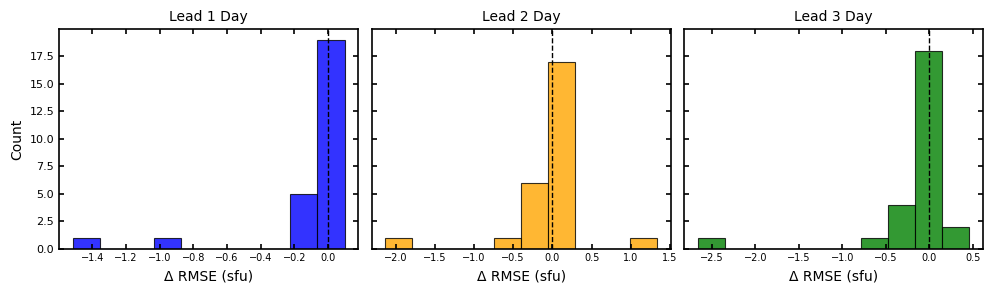

In [65]:
# ---------------------------------------
# Prepare data
# ---------------------------------------
delta_cols = ['delta1', 'delta2', 'delta3']
colors = {1: "blue", 2: "orange", 3: "green"}

# ---------------------------------------
# Create figure
# ---------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharey=True)

for i, col in enumerate(delta_cols):

    lead = i + 1
    data = diff_rsga_swpc_verif[col].dropna()

    axes[i].hist(
        data,
        bins=10,
        edgecolor='black',
        linewidth=0.8,
        alpha=0.8,
        color=colors[lead]
    )

    axes[i].axvline(0, color='black', linestyle='--', linewidth=1)
    axes[i].set_title(f"Lead {lead} Day")
    axes[i].set_xlabel("Δ RMSE (sfu)")

axes[0].set_ylabel("Count")

plt.tight_layout()
plt.show()

#### Single frame version of the above histogram comparison with outliers annotated

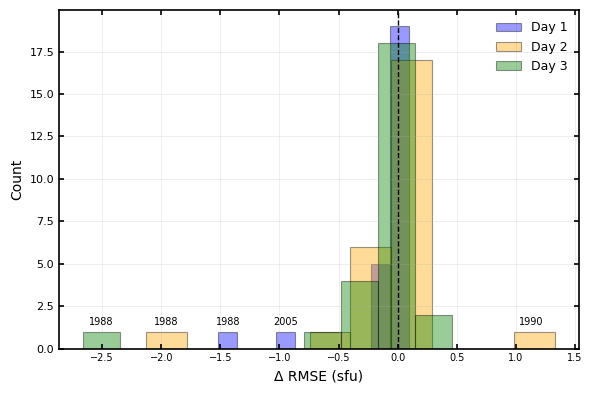

In [157]:
# -------------------------------------------------
# AGU / Space Weather styling
# -------------------------------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 7,
    "ytick.labelsize": 8,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "legend.frameon": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

delta_cols = ['delta1', 'delta2', 'delta3']
colors = {1: "blue", 2: "orange", 3: "green"}

plt.figure(figsize=(6,4))

for i, col in enumerate(delta_cols):

    lead = i + 1

    data = diff_rsga_swpc_verif[col]
    years = diff_rsga_swpc_verif['year']

    # Remove NaNs
    mask = ~data.isna()
    data = data[mask].values
    years = years[mask].values

    # ---- Histogram (capture counts + bins) ----
    counts, bins, patches = plt.hist(
        data,
        bins=10,
        alpha=0.4,
        edgecolor='black',
        linewidth=0.8,
        label=f"Day {lead}",
        color=colors[lead]
    )

    # ---- Annotate |delta| > 1 ----
    for x_val, yr in zip(data, years):

        if np.abs(x_val) > 0.9:

            # Find which bin this value falls into
            bin_index = np.digitize(x_val, bins) - 1

            # Safety check
            if 0 <= bin_index < len(counts):

                bin_center = 0.5 * (bins[bin_index] + bins[bin_index+1])
                bin_height = counts[bin_index]

                plt.annotate(
                    str(int(yr)),
                    xy=(bin_center, bin_height),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center',
                    va='bottom',
                    fontsize=7,
                    color='black'
                )
            if yr == 1990:
                plt.annotate(
                    str(int(1990)),  # for some reason the code above isn't annotating the 1990 point, so I'm adding it manually here
                    xy=(x_val-0.2, 1),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center',
                    va='bottom',
                    fontsize=7,
                    color='black'
        )
# Reference line
plt.axvline(0, color='black', linestyle='--', linewidth=1)

plt.xlabel("Δ RMSE (sfu)")
plt.ylabel("Count")
plt.legend()
plt.grid(True, linestyle='-', linewidth=0.5, alpha=0.3)

plt.tight_layout()
#plt.savefig("verification_paper_figures/RSGA_vs_SWPC_verification_RMSE_deltas_histogram.png", dpi=300)
plt.show()

In [164]:
df_acc


,issued_date,observed,forecast_day1,forecast_day2,forecast_day3,observed_day1,observed_day2,observed_day3,err_day1,err_day2,...,recurrence_day1,recurrence_day2,recurrence_day3,3-day mean reference,year,f107_27d,total sunspot_number,ssn_27d,ssn_81d,f107_81d
0,1988-06-28,178.0,185.0,180.0,175.0,183.0,184.0,193.0,2.0,-4.0,...,150.0,144.0,145.0,162.666667,1988,164.214286,142,134.571429,139.073171,157.853659
1,1988-06-29,183.0,185.0,180.0,170.0,184.0,193.0,192.0,1.0,-13.0,...,144.0,145.0,147.0,172.000000,1988,162.133333,148,134.000000,140.523810,158.404762
2,1988-06-30,184.0,184.0,184.0,183.0,193.0,192.0,187.0,-9.0,-8.0,...,145.0,147.0,147.0,181.666667,1988,160.625000,148,133.062500,142.232558,158.906977
3,1988-07-01,193.0,194.0,194.0,193.0,192.0,187.0,175.0,2.0,7.0,...,147.0,147.0,154.0,186.666667,1988,159.705882,160,133.470588,143.318182,159.386364
4,1988-07-02,192.0,192.0,192.0,191.0,187.0,175.0,166.0,5.0,17.0,...,147.0,154.0,160.0,189.666667,1988,158.944444,167,133.833333,143.888889,159.688889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13546,2025-12-24,134.0,150.0,155.0,160.0,163.0,166.0,178.0,-13.0,-11.0,...,120.0,138.0,160.0,136.333333,2025,136.555556,131,97.000000,105.933333,147.022222
13547,2025-12-25,163.0,165.0,170.0,175.0,166.0,178.0,188.0,-1.0,-8.0,...,138.0,160.0,180.0,146.333333,2025,136.000000,128,95.588235,106.000000,147.068182
13548,2025-12-26,166.0,170.0,175.0,170.0,178.0,188.0,196.0,-8.0,-13.0,...,160.0,180.0,196.0,154.333333,2025,136.062500,126,95.437500,106.139535,147.418605
13549,2025-12-27,178.0,175.0,170.0,160.0,188.0,196.0,182.0,-13.0,-26.0,...,180.0,196.0,200.0,169.000000,2025,137.000000,150,96.066667,106.976190,147.785714


#### Time series comparisons by year using RMSE, MAE, DTW, and TWED metrics for verification

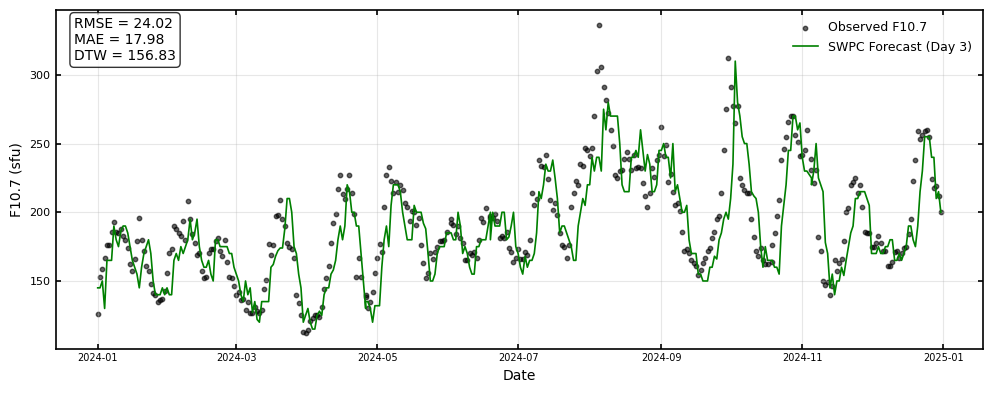

In [ ]:

from sklearn.metrics import mean_squared_error, mean_absolute_error
from dtaidistance import dtw
#from tslearn.metrics import twed.   TWED is not a metric in tslearn. 

# -------------------------------------------------
# 2024 forecast verification (scatter + metrics)
# -------------------------------------------------

df_acc['issued_date'] = pd.to_datetime(df_acc['issued_date'])

df_sc25 = df_acc[(df_acc['issued_date'] >= "2024-01-01") & (df_acc['issued_date'] <= "2024-12-31")].copy()

obs = df_sc25['observed_day3'].values
fcst = df_sc25['forecast_day3'].values
dates = df_sc25['issued_date']

mask = (~np.isnan(obs)) & (~np.isnan(fcst))
obs = obs[mask]
fcst = fcst[mask]
dates = dates[mask]

# -------------------------------------------------
# Verification metrics
# -------------------------------------------------

rmse = np.sqrt(mean_squared_error(obs, fcst))
mae = mean_absolute_error(obs, fcst)

# DTW
dtw_dist = dtw.distance(obs, fcst)

# TWED (parameters commonly used in literature)
#twed_dist = twed(obs.reshape(-1,1),
#                 fcst.reshape(-1,1),
#                 lambda_=1,
#                 nu=0.001)

# -------------------------------------------------
# Plot
# -------------------------------------------------

plt.figure(figsize=(10,4))

plt.scatter(dates, obs,
         marker="o",
         s=10,
         alpha=0.6,
         color="black",
         label='Observed F10.7')

plt.plot(dates, fcst,
         color='blue',
         linewidth=1.2,
         label='SWPC Forecast (Day 3)')

plt.ylabel("F10.7 (sfu)")
plt.xlabel("Date")
#plt.title("Solar Cycle 25 F10.7 Forecast Verification")

plt.legend()

# -------------------------------------------------
# Metrics annotation box
# -------------------------------------------------

textstr = '\n'.join((
    f'RMSE = {rmse:.2f}',
    f'MAE = {mae:.2f}',
    f'DTW = {dtw_dist:.2f}' #,
    # f'TWED = {twed_dist:.2f}'
))

plt.gca().text(0.02, 0.98,
               textstr,
               transform=plt.gca().transAxes,
               fontsize=10,
               verticalalignment='top',
               bbox=dict(boxstyle="round",
                         facecolor="white",
                         alpha=0.8))

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("verification_paper_figures/SC25_F10.7_forecast_verification_day1_2024.png", dpi=300)
plt.show()

#### DTW analysis using dtaidistance.readthedocs.io

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from dtaidistance import dtw
from dtaidistance import dtw_visualisation as dtwvis
print(dtwvis.__file__)

import.reload(dtwvis)    

#from tslearn.metrics import twed.   TWED is not a metric in tslearn. 

# -------------------------------------------------
# 2024 forecast verification (scatter + metrics)
# -------------------------------------------------

df_acc['issued_date'] = pd.to_datetime(df_acc['issued_date'])

df_sc25 = df_acc[(df_acc['issued_date'] >= "2024-01-01") & (df_acc['issued_date'] <= "2024-12-31")].copy()

obs = df_sc25['observed_day2'].values
fcst = df_sc25['forecast_day2'].values
dates = df_sc25['issued_date']

mask = (~np.isnan(obs)) & (~np.isnan(fcst))
obs = obs[mask]
fcst = fcst[mask]
new_fcst = fcst.copy()  # Create a copy for warping visualization   
dates = dates[mask]

# -------------------------------------------------
# Verification metrics
# -------------------------------------------------
rmse = np.sqrt(mean_squared_error(obs, fcst))
mae = mean_absolute_error(obs, fcst)

# DTW
dtw_dist = dtw.distance(obs, fcst)

#-------------------------------------------------
# Plot DTW warping path
#-------------------------------------------------
path = dtw.warping_path(fcst, obs)
#fig, ax = dtwvis.plot_warping_single_ax(fcst, obs, path=path,series_line_options={"color": "blue", "linewidth": 1.2}, 
                                         #series2_line_options={"color": "black", "linewidth": 1.2},
                                         #warping_path_options={"color": "orange", "linewidth": 1, "alpha": 0.7})

fig,ax = dtwvis.plot_warping_single_ax(fcst, obs, path=path)

ax.set_title("DTW Warping Path\n(2024 F10.7 2-day Forecast vs Observed)")

textstr = '\n'.join((
    f'RMSE = {rmse:.2f}',
    f'MAE = {mae:.2f}',
    f'DTW = {dtw_dist:.2f}' #,
    # f'TWED = {twed_dist:.2f}'
))

plt.gca().text(0.02, 0.78,
               textstr,
               transform=plt.gca().transAxes,
               fontsize=10,
               verticalalignment='top',
               bbox=dict(boxstyle="round",
                         facecolor="white",
                         alpha=0.8))

plt.legend(["Forecast", "Observed"], loc="upper left")
plt.tight_layout()
plt.savefig("verification_paper_figures/2024_2-day_F10.7_DTW_warping_path.png", dpi=300)
plt.show()  

/Users/tberger/Library/CloudStorage/GoogleDrive-tberger@ucar.edu/My Drive/Research/LWS-FST Far-Side F10/F10.7 Forecast Verification/.venv/lib/python3.14/site-packages/dtaidistance/dtw_visualisation.py


NameError: name 'importlib' is not defined